In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pennylane as qml
from qlstm_pennylane import QLSTM


# preprocessing

In [10]:
df_half_hour=pd.read_csv('daily_max_temp_SDL.csv')
df_half_hour.isna().sum()

dwpf      0
relh      0
drct      0
sknt      0
alti      0
mslp      0
vsby      0
temp_c    0
dtype: int64

In [11]:
daily_max_temp=df_half_hour
daily_max_temp

,dwpf,relh,drct,sknt,alti,mslp,vsby,temp_c
0,14.0,12.74,184.994451,3.0,30.14,1019.7,10.0,19.444444
1,26.0,19.77,310.000000,5.0,30.03,1015.7,10.0,20.555556
2,23.0,16.26,0.000000,0.0,30.07,1017.3,10.0,21.666667
3,21.0,14.51,120.000000,6.0,30.07,1017.2,10.0,22.222222
4,25.0,17.67,240.000000,4.0,30.05,1016.3,10.0,21.666667
...,...,...,...,...,...,...,...,...
5402,39.0,14.78,180.000000,7.0,29.81,1006.8,10.0,34.444444
5403,38.0,16.10,270.000000,6.0,29.78,1006.2,10.0,32.222222
5404,47.0,28.45,250.000000,3.0,29.71,1003.7,10.0,28.333333
5405,37.0,30.84,140.000000,4.0,30.06,1016.3,10.0,20.555556


In [12]:
percentile_90 = np.percentile(daily_max_temp['temp_c'], 90)
print(f"90th Percentile of max_temp_c: {percentile_90}")
daily_max_temp

90th Percentile of max_temp_c: 41.11111111111112


,dwpf,relh,drct,sknt,alti,mslp,vsby,temp_c
0,14.0,12.74,184.994451,3.0,30.14,1019.7,10.0,19.444444
1,26.0,19.77,310.000000,5.0,30.03,1015.7,10.0,20.555556
2,23.0,16.26,0.000000,0.0,30.07,1017.3,10.0,21.666667
3,21.0,14.51,120.000000,6.0,30.07,1017.2,10.0,22.222222
4,25.0,17.67,240.000000,4.0,30.05,1016.3,10.0,21.666667
...,...,...,...,...,...,...,...,...
5402,39.0,14.78,180.000000,7.0,29.81,1006.8,10.0,34.444444
5403,38.0,16.10,270.000000,6.0,29.78,1006.2,10.0,32.222222
5404,47.0,28.45,250.000000,3.0,29.71,1003.7,10.0,28.333333
5405,37.0,30.84,140.000000,4.0,30.06,1016.3,10.0,20.555556


# some functions needed

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.optimizers import Adam  # Import the Adam optimizer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Normalize data
def normalize_data(data):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaled_data = scaler.fit_transform(data)
    return scaled_data, scaler

# Create sequences for training/testing
def create_sequences(data, sequence_length):
    sequences, labels = [], []
    for i in range(len(data) - sequence_length):
        sequences.append(data[i:i + sequence_length])
        labels.append(data[i + sequence_length])
    return np.array(sequences), np.array(labels)

# Build and compile LSTM model
def build_lstm_model(input_shape, learning_rate=0.001):
    model = Sequential()
    model.add(LSTM(50, return_sequences=False, input_shape=input_shape))
    model.add(Dense(input_shape[-1]))  # Output neurons equal to feature count
    
    # Create the Adam optimizer with the specified learning rate
    optimizer = Adam(learning_rate=learning_rate)
    
    # Compile the model with the optimizer and loss function
    model.compile(optimizer=optimizer, loss="mean_squared_error", metrics=["mae"])
    return model

# Function to plot loss, accuracy, and predictions
def plot_metrics_and_predictions(history, y_test_rescaled, predictions_rescaled, temp_c_index):
    # Loss and Validation Loss Plot
    plt.figure(figsize=(10, 4))
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Predictions vs Actuals for temp_c
    plt.figure(figsize=(10, 4))
    plt.plot(predictions_rescaled[:, temp_c_index], label="Predicted temp_c")
    plt.plot(y_test_rescaled[:, temp_c_index], label="Actual temp_c")
    plt.xlabel("Time")
    plt.ylabel("Temperature (temp_c)")
    plt.legend()
    plt.show()

def iterative_forecast_map(model, x_test, days_to_predict, scaler):
    model.eval()  # Set model to evaluation mode
    n_samples, seq_len, n_features = x_test.shape
    prediction_dict = {}

    for step in range(1, days_to_predict + 1):
        predictions = []

        for i in range(n_samples - step + 1):
            sequence = x_test[i]  # Shape: (seq_len, n_features)

            # Perform recursive prediction for t in [0, step-1)
            for t in range(step - 1):
                input_tensor = torch.tensor(sequence[np.newaxis, :, :], dtype=torch.float32)  # Add batch dimension
                with torch.no_grad():
                    prediction = model(input_tensor)
                prediction = prediction.numpy().reshape(1, n_features)
                sequence = np.vstack((sequence[1:], prediction))  # Update sequence

            # Final prediction for current step
            input_tensor = torch.tensor(sequence[np.newaxis, :, :], dtype=torch.float32)
            with torch.no_grad():
                final_prediction = model(input_tensor)

            final_prediction_np = final_prediction.numpy()
            predictions.append(final_prediction_np[0])  # shape: (n_features,)

        # Inverse transform and reshape
        predictions = scaler.inverse_transform(np.array(predictions))
        prediction_dict[step] = predictions.reshape(-1, 1, n_features)

    return prediction_dict





# try traning each function alone.


🔁 Training model for: dwpf
Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 1)
Epoch 10/300, Loss: 0.1153
Epoch 20/300, Loss: 0.1266
Epoch 30/300, Loss: 0.1136
Epoch 40/300, Loss: 0.1151
Epoch 50/300, Loss: 0.1131
Epoch 60/300, Loss: 0.1129
Epoch 70/300, Loss: 0.1117
Epoch 80/300, Loss: 0.1096
Epoch 90/300, Loss: 0.1047
Epoch 100/300, Loss: 0.0940
Epoch 110/300, Loss: 0.0742
Epoch 120/300, Loss: 0.0493
Epoch 130/300, Loss: 0.0357
Epoch 140/300, Loss: 0.0350
Epoch 150/300, Loss: 0.0340
Epoch 160/300, Loss: 0.0334
Epoch 170/300, Loss: 0.0333
Epoch 180/300, Loss: 0.0332
Epoch 190/300, Loss: 0.0331
Epoch 200/300, Loss: 0.0330
Epoch 210/300, Loss: 0.0329
Epoch 220/300, Loss: 0.0328
Epoch 230/300, Loss: 0.0328
Epoch 240/300, Loss: 0.0327
Epoch 250/300, Loss: 0.0327
Epoch 260/300, Loss: 0.0327
Epoch 270/300, Loss: 0.0326
Epoch 280/300, Loss: 0.0326
Epoch 290/300, Loss: 0.0325
Epoch 300/300, Loss: 0.0325


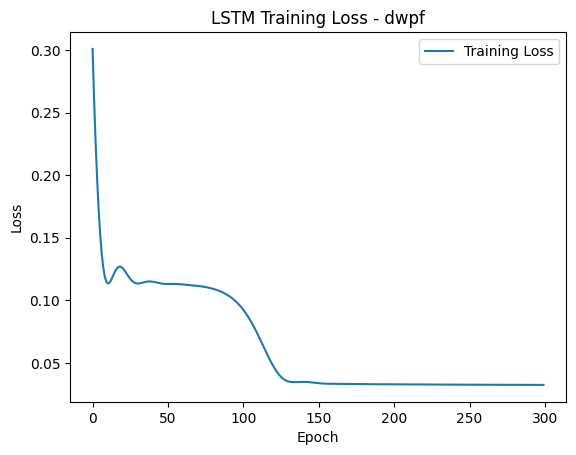

📊 Metrics for dwpf:
   R² Score : 0.7574
   MSE      : 0.0293
   MAE      : 0.1232


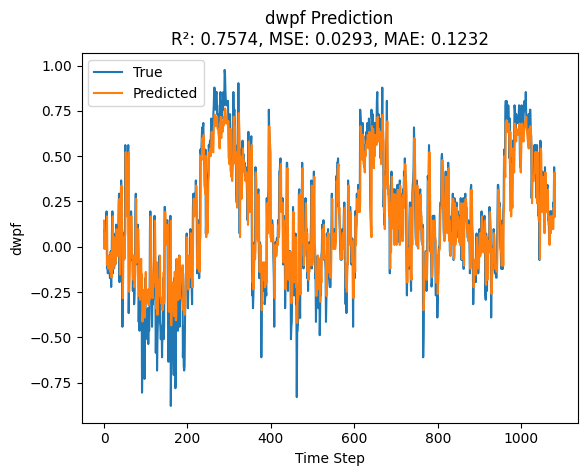


🔁 Training model for: relh
Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 1)
Epoch 10/300, Loss: 0.1154
Epoch 20/300, Loss: 0.0676
Epoch 30/300, Loss: 0.0706
Epoch 40/300, Loss: 0.0630
Epoch 50/300, Loss: 0.0637
Epoch 60/300, Loss: 0.0623
Epoch 70/300, Loss: 0.0621
Epoch 80/300, Loss: 0.0614
Epoch 90/300, Loss: 0.0607
Epoch 100/300, Loss: 0.0596
Epoch 110/300, Loss: 0.0579
Epoch 120/300, Loss: 0.0555
Epoch 130/300, Loss: 0.0516
Epoch 140/300, Loss: 0.0455
Epoch 150/300, Loss: 0.0367
Epoch 160/300, Loss: 0.0290
Epoch 170/300, Loss: 0.0278
Epoch 180/300, Loss: 0.0278
Epoch 190/300, Loss: 0.0273
Epoch 200/300, Loss: 0.0272
Epoch 210/300, Loss: 0.0270
Epoch 220/300, Loss: 0.0269
Epoch 230/300, Loss: 0.0268
Epoch 240/300, Loss: 0.0267
Epoch 250/300, Loss: 0.0265
Epoch 260/300, Loss: 0.0264
Epoch 270/300, Loss: 0.0264
Epoch 280/300, Loss: 0.0263
Epoch 290/300, Loss: 0.0262
Epoch 300/300, Loss: 0.0261


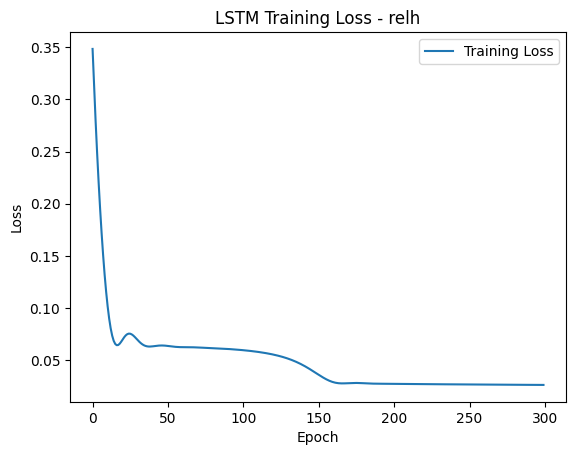

📊 Metrics for relh:
   R² Score : 0.6205
   MSE      : 0.0284
   MAE      : 0.1076


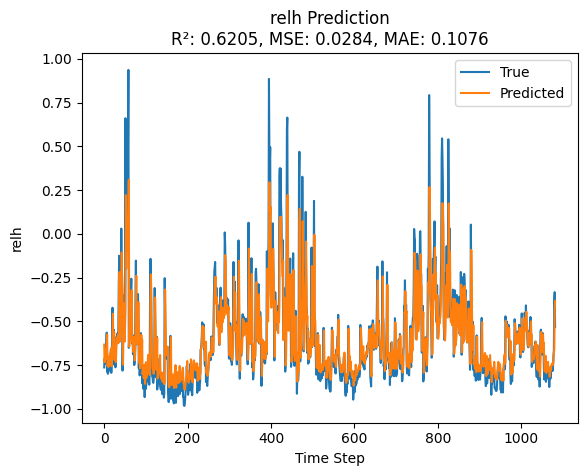


🔁 Training model for: drct
Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 1)
Epoch 10/300, Loss: 0.3070
Epoch 20/300, Loss: 0.2896
Epoch 30/300, Loss: 0.2769
Epoch 40/300, Loss: 0.2784
Epoch 50/300, Loss: 0.2767
Epoch 60/300, Loss: 0.2769
Epoch 70/300, Loss: 0.2767
Epoch 80/300, Loss: 0.2766
Epoch 90/300, Loss: 0.2766
Epoch 100/300, Loss: 0.2765
Epoch 110/300, Loss: 0.2764
Epoch 120/300, Loss: 0.2763
Epoch 130/300, Loss: 0.2762
Epoch 140/300, Loss: 0.2761
Epoch 150/300, Loss: 0.2760
Epoch 160/300, Loss: 0.2759
Epoch 170/300, Loss: 0.2757
Epoch 180/300, Loss: 0.2755
Epoch 190/300, Loss: 0.2753
Epoch 200/300, Loss: 0.2751
Epoch 210/300, Loss: 0.2749
Epoch 220/300, Loss: 0.2747
Epoch 230/300, Loss: 0.2746
Epoch 240/300, Loss: 0.2744
Epoch 250/300, Loss: 0.2743
Epoch 260/300, Loss: 0.2742
Epoch 270/300, Loss: 0.2741
Epoch 280/300, Loss: 0.2741
Epoch 290/300, Loss: 0.2741
Epoch 300/300, Loss: 0.2740


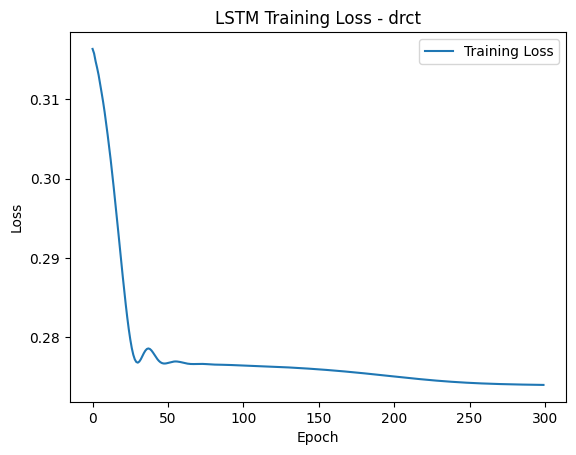

📊 Metrics for drct:
   R² Score : 0.2032
   MSE      : 0.2416
   MAE      : 0.3919


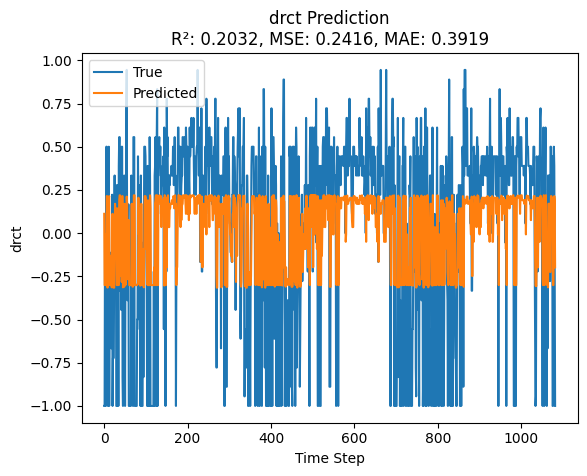


🔁 Training model for: sknt
Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 1)
Epoch 10/300, Loss: 0.0626
Epoch 20/300, Loss: 0.0761
Epoch 30/300, Loss: 0.0619
Epoch 40/300, Loss: 0.0632
Epoch 50/300, Loss: 0.0617
Epoch 60/300, Loss: 0.0613
Epoch 70/300, Loss: 0.0612
Epoch 80/300, Loss: 0.0609
Epoch 90/300, Loss: 0.0606
Epoch 100/300, Loss: 0.0603
Epoch 110/300, Loss: 0.0599
Epoch 120/300, Loss: 0.0593
Epoch 130/300, Loss: 0.0586
Epoch 140/300, Loss: 0.0578
Epoch 150/300, Loss: 0.0569
Epoch 160/300, Loss: 0.0560
Epoch 170/300, Loss: 0.0556
Epoch 180/300, Loss: 0.0554
Epoch 190/300, Loss: 0.0554
Epoch 200/300, Loss: 0.0554
Epoch 210/300, Loss: 0.0554
Epoch 220/300, Loss: 0.0554
Epoch 230/300, Loss: 0.0554
Epoch 240/300, Loss: 0.0554
Epoch 250/300, Loss: 0.0553
Epoch 260/300, Loss: 0.0553
Epoch 270/300, Loss: 0.0553
Epoch 280/300, Loss: 0.0553
Epoch 290/300, Loss: 0.0553
Epoch 300/300, Loss: 0.0553


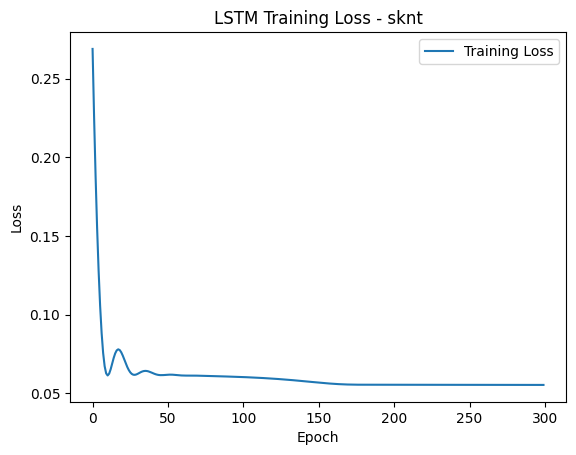

📊 Metrics for sknt:
   R² Score : 0.0836
   MSE      : 0.0510
   MAE      : 0.1709


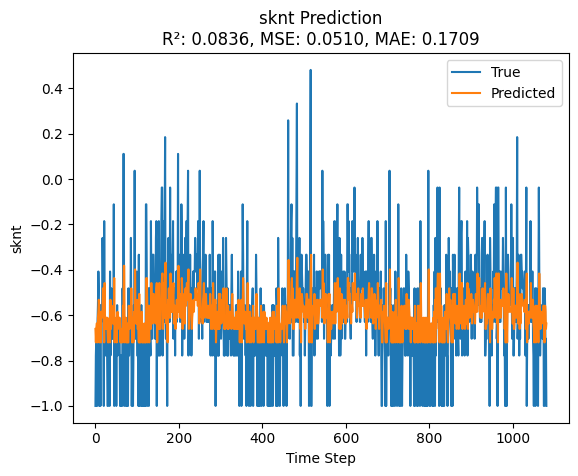


🔁 Training model for: alti
Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 1)
Epoch 10/300, Loss: 0.0639
Epoch 20/300, Loss: 0.0600
Epoch 30/300, Loss: 0.0599
Epoch 40/300, Loss: 0.0581
Epoch 50/300, Loss: 0.0547
Epoch 60/300, Loss: 0.0479
Epoch 70/300, Loss: 0.0375
Epoch 80/300, Loss: 0.0294
Epoch 90/300, Loss: 0.0288
Epoch 100/300, Loss: 0.0288
Epoch 110/300, Loss: 0.0284
Epoch 120/300, Loss: 0.0285
Epoch 130/300, Loss: 0.0284
Epoch 140/300, Loss: 0.0284
Epoch 150/300, Loss: 0.0284
Epoch 160/300, Loss: 0.0284
Epoch 170/300, Loss: 0.0284
Epoch 180/300, Loss: 0.0284
Epoch 190/300, Loss: 0.0284
Epoch 200/300, Loss: 0.0284
Epoch 210/300, Loss: 0.0284
Epoch 220/300, Loss: 0.0284
Epoch 230/300, Loss: 0.0284
Epoch 240/300, Loss: 0.0284
Epoch 250/300, Loss: 0.0284
Epoch 260/300, Loss: 0.0284
Epoch 270/300, Loss: 0.0284
Epoch 280/300, Loss: 0.0284
Epoch 290/300, Loss: 0.0284
Epoch 300/300, Loss: 0.0284


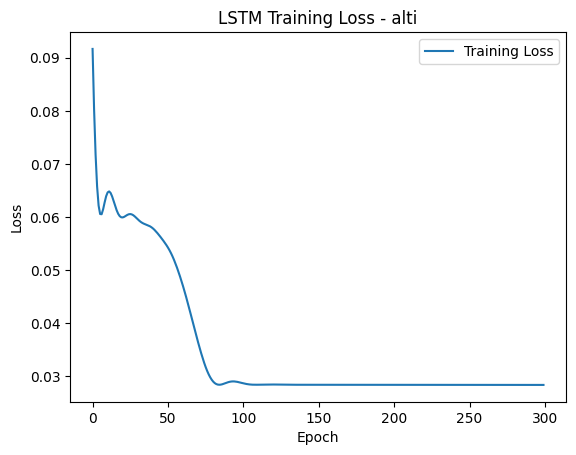

📊 Metrics for alti:
   R² Score : 0.5116
   MSE      : 0.0308
   MAE      : 0.1276


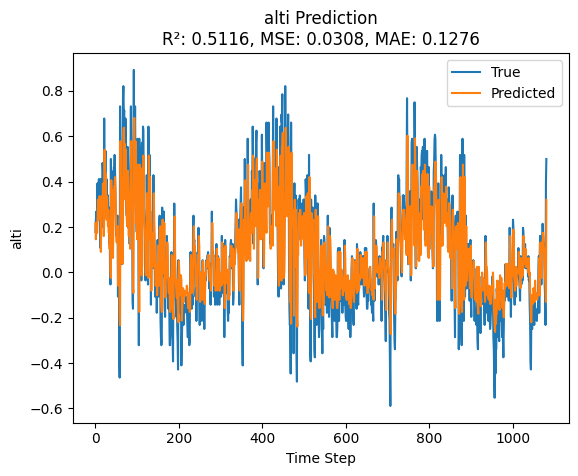


🔁 Training model for: mslp
Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 1)
Epoch 10/300, Loss: 0.0827
Epoch 20/300, Loss: 0.0760
Epoch 30/300, Loss: 0.0647
Epoch 40/300, Loss: 0.0466
Epoch 50/300, Loss: 0.0328
Epoch 60/300, Loss: 0.0343
Epoch 70/300, Loss: 0.0325
Epoch 80/300, Loss: 0.0327
Epoch 90/300, Loss: 0.0324
Epoch 100/300, Loss: 0.0324
Epoch 110/300, Loss: 0.0323
Epoch 120/300, Loss: 0.0323
Epoch 130/300, Loss: 0.0323
Epoch 140/300, Loss: 0.0323
Epoch 150/300, Loss: 0.0323
Epoch 160/300, Loss: 0.0323
Epoch 170/300, Loss: 0.0323
Epoch 180/300, Loss: 0.0323
Epoch 190/300, Loss: 0.0323
Epoch 200/300, Loss: 0.0323
Epoch 210/300, Loss: 0.0323
Epoch 220/300, Loss: 0.0323
Epoch 230/300, Loss: 0.0323
Epoch 240/300, Loss: 0.0323
Epoch 250/300, Loss: 0.0323
Epoch 260/300, Loss: 0.0323
Epoch 270/300, Loss: 0.0323
Epoch 280/300, Loss: 0.0323
Epoch 290/300, Loss: 0.0323
Epoch 300/300, Loss: 0.0323


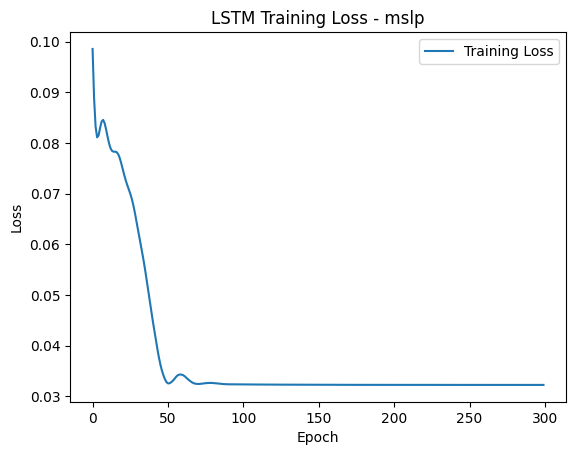

📊 Metrics for mslp:
   R² Score : 0.5922
   MSE      : 0.0351
   MAE      : 0.1342


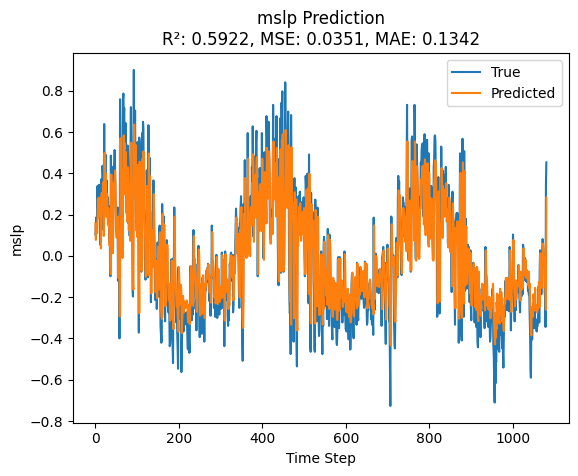


🔁 Training model for: vsby
Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 1)
Epoch 10/300, Loss: 0.5068
Epoch 20/300, Loss: 0.1075
Epoch 30/300, Loss: 0.0027
Epoch 40/300, Loss: 0.0176
Epoch 50/300, Loss: 0.0071
Epoch 60/300, Loss: 0.0028
Epoch 70/300, Loss: 0.0035
Epoch 80/300, Loss: 0.0027
Epoch 90/300, Loss: 0.0027
Epoch 100/300, Loss: 0.0027
Epoch 110/300, Loss: 0.0027
Epoch 120/300, Loss: 0.0027
Epoch 130/300, Loss: 0.0027
Epoch 140/300, Loss: 0.0027
Epoch 150/300, Loss: 0.0027
Epoch 160/300, Loss: 0.0027
Epoch 170/300, Loss: 0.0027
Epoch 180/300, Loss: 0.0027
Epoch 190/300, Loss: 0.0027
Epoch 200/300, Loss: 0.0027
Epoch 210/300, Loss: 0.0027
Epoch 220/300, Loss: 0.0027
Epoch 230/300, Loss: 0.0027
Epoch 240/300, Loss: 0.0027
Epoch 250/300, Loss: 0.0027
Epoch 260/300, Loss: 0.0027
Epoch 270/300, Loss: 0.0027
Epoch 280/300, Loss: 0.0027
Epoch 290/300, Loss: 0.0027
Epoch 300/300, Loss: 0.0027


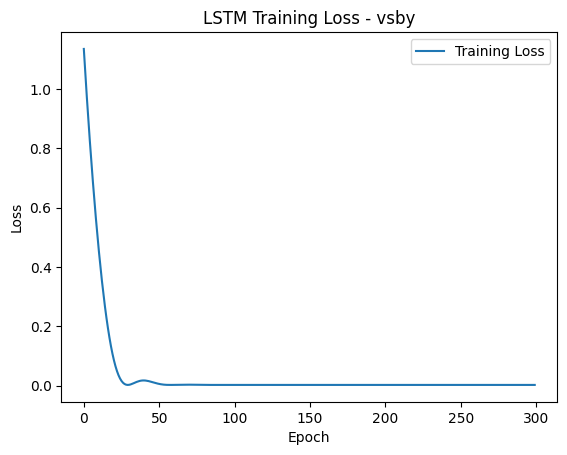

📊 Metrics for vsby:
   R² Score : -0.0908
   MSE      : 0.0001
   MAE      : 0.0027


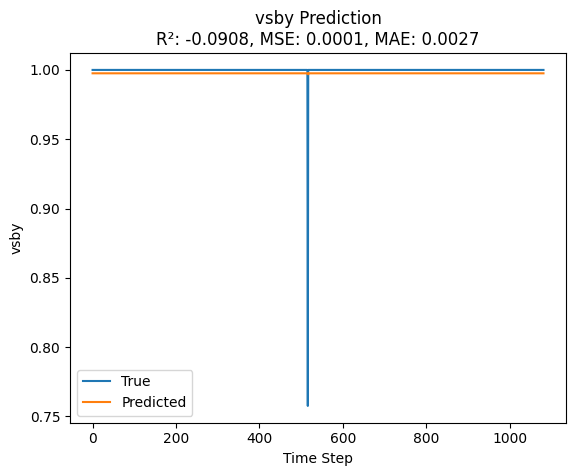


🔁 Training model for: temp_c
Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 1)
Epoch 10/300, Loss: 0.1712
Epoch 20/300, Loss: 0.1569
Epoch 30/300, Loss: 0.1220
Epoch 40/300, Loss: 0.0634
Epoch 50/300, Loss: 0.0154
Epoch 60/300, Loss: 0.0164
Epoch 70/300, Loss: 0.0126
Epoch 80/300, Loss: 0.0122
Epoch 90/300, Loss: 0.0120
Epoch 100/300, Loss: 0.0118
Epoch 110/300, Loss: 0.0118
Epoch 120/300, Loss: 0.0118
Epoch 130/300, Loss: 0.0118
Epoch 140/300, Loss: 0.0118
Epoch 150/300, Loss: 0.0118
Epoch 160/300, Loss: 0.0117
Epoch 170/300, Loss: 0.0117
Epoch 180/300, Loss: 0.0117
Epoch 190/300, Loss: 0.0117
Epoch 200/300, Loss: 0.0117
Epoch 210/300, Loss: 0.0117
Epoch 220/300, Loss: 0.0117
Epoch 230/300, Loss: 0.0117
Epoch 240/300, Loss: 0.0117
Epoch 250/300, Loss: 0.0117
Epoch 260/300, Loss: 0.0117
Epoch 270/300, Loss: 0.0117
Epoch 280/300, Loss: 0.0117
Epoch 290/300, Loss: 0.0117
Epoch 300/300, Loss: 0.0117


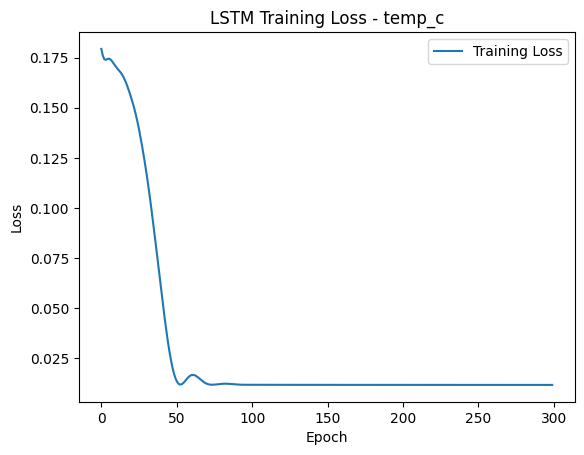

📊 Metrics for temp_c:
   R² Score : 0.9482
   MSE      : 0.0102
   MAE      : 0.0740


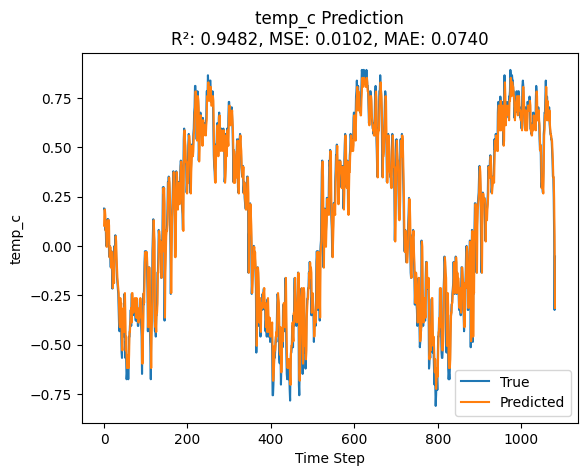

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Assume normalize_data and LSTMRegressor are defined

sequence_length = 1
num_epochs = 300
Qinput_dim = 1
Qhidden_dim = 16
Qn_qubits = 1
backend = 'default.qubit'

for column in daily_max_temp.columns:
    print(f"\n🔁 Training model for: {column}")

    # Normalize and reshape
    data = daily_max_temp[column].values.reshape(-1, 1)
    data, scaler = normalize_data(data)
    
    # Create sequences
    def create_sequences(data, sequence_length):
        sequences, labels = [], []
        for i in range(len(data) - sequence_length):
            sequences.append(data[i:i + sequence_length])
            labels.append(data[i + sequence_length])
        return np.array(sequences), np.array(labels)
    
    X, y = create_sequences(data, sequence_length)
    
    # Train/test split
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
    
    # Initialize model
    model = LSTMRegressor(Qinput_dim, Qhidden_dim, n_qubits=Qn_qubits, backend=backend)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_function = nn.MSELoss()
    
    # Train model
    loss_history = []
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = loss_function(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")
    
    # Plot training loss
    plt.figure()
    plt.plot(loss_history, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'LSTM Training Loss - {column}')
    plt.legend()
    plt.show()
    
    # Predict and evaluate
    model.eval()
    y_pred = model(X_test_tensor).detach().numpy()

    # Evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"📊 Metrics for {column}:")
    print(f"   R² Score : {r2:.4f}")
    print(f"   MSE      : {mse:.4f}")
    print(f"   MAE      : {mae:.4f}")
    
    # Plot prediction
    plt.figure()
    plt.plot(range(len(y_test)), y_test, label='True')
    plt.plot(range(len(y_test)), y_pred, label='Predicted')
    plt.legend()
    plt.title(f'{column} Prediction\nR²: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}')
    plt.xlabel('Time Step')
    plt.ylabel(column)
    plt.show()


# sequances lenth 1 and 1 qubit

In [ ]:
data=daily_max_temp['temp_c'].values.reshape(-1,1)
data,scaler=normalize_data(data)


In [7]:
# Create sequences for training/testing
def create_sequences(data, sequence_length):
    sequences, labels = [], []
    for i in range(len(data) - sequence_length):
        sequences.append(data[i:i + sequence_length])
        labels.append(data[i + sequence_length])
    return np.array(sequences), np.array(labels)
# Initialize variables
sequence_length =1

# Make a copy of the original DataFrame to update
updated_data = data.copy()

X, y = create_sequences(updated_data, sequence_length)

# Train-test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"data X train shape: {X_train.shape},data X test shape: {X_test.shape}")
print(f"data y train shape: {y_train.shape},data y test shape: {y_test.shape}")



data X train shape: (4324, 1, 1),data X test shape: (1082, 1, 1)
data y train shape: (4324, 1),data y test shape: (1082, 1)


In [8]:
# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [9]:
# Define LSTM model
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_qubits=0,n_qlayers=1, backend='default.qubit'):
        super(LSTMRegressor, self).__init__()
        self.hidden_dim = hidden_dim
        
        if n_qubits > 0:
            print(f"Using Quantum LSTM on backend {backend}")
            self.lstm = QLSTM(input_dim, hidden_dim, n_qubits=n_qubits,n_qlayers=n_qlayers ,backend=backend)
        else:
            print("Using Classical LSTM")
            self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x.view(x.shape[0], x.shape[1], -1))
        output = self.fc(lstm_out[:, -1])  # Predict next value
        return output

In [10]:
# Model parameters
Qinput_dim = 1
Qhidden_dim = 16
Qn_qubits = 1
backend = 'default.qubit'

Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 1)
Epoch 10/300, Loss: 0.1760
Epoch 20/300, Loss: 0.1759
Epoch 30/300, Loss: 0.1736
Epoch 40/300, Loss: 0.1675
Epoch 50/300, Loss: 0.1505
Epoch 60/300, Loss: 0.1070
Epoch 70/300, Loss: 0.0421
Epoch 80/300, Loss: 0.0131
Epoch 90/300, Loss: 0.0168
Epoch 100/300, Loss: 0.0127
Epoch 110/300, Loss: 0.0131
Epoch 120/300, Loss: 0.0124
Epoch 130/300, Loss: 0.0124
Epoch 140/300, Loss: 0.0122
Epoch 150/300, Loss: 0.0122
Epoch 160/300, Loss: 0.0121
Epoch 170/300, Loss: 0.0120
Epoch 180/300, Loss: 0.0120
Epoch 190/300, Loss: 0.0120
Epoch 200/300, Loss: 0.0119
Epoch 210/300, Loss: 0.0119
Epoch 220/300, Loss: 0.0119
Epoch 230/300, Loss: 0.0119
Epoch 240/300, Loss: 0.0119
Epoch 250/300, Loss: 0.0118
Epoch 260/300, Loss: 0.0118
Epoch 270/300, Loss: 0.0118
Epoch 280/300, Loss: 0.0118
Epoch 290/300, Loss: 0.0118
Epoch 300/300, Loss: 0.0118


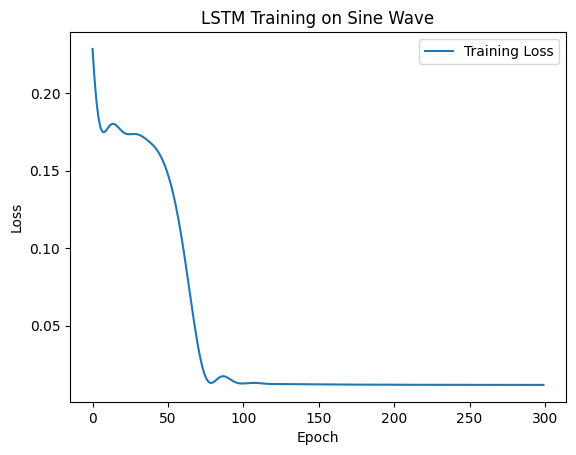

x test len:1082



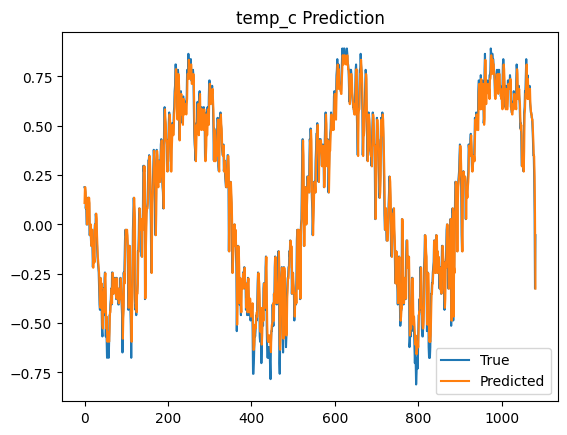

y test len:1082

y predicted len:1082

y orignal test len:1082

y orignal predicted len:1082



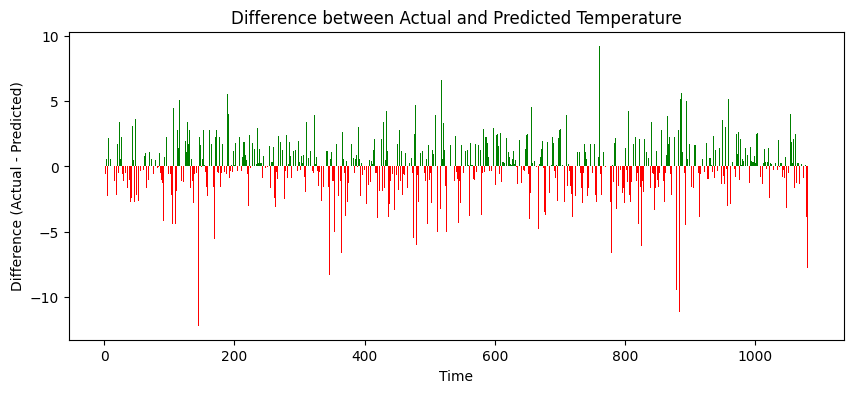

R² Score: 0.9478
Mean Squared Error (MSE): 4.3629
Mean Absolute Error (MAE): 1.5264
Root Mean Squared Error (RMSE): 2.0888


In [11]:
model = LSTMRegressor(Qinput_dim, Qhidden_dim, n_qubits=Qn_qubits, backend=backend)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_function = nn.MSELoss()

# Training loop
num_epochs = 300
loss_history = []
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = loss_function(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training on Sine Wave')
plt.legend()
plt.show()
print(f'x test len:{len(X_test_tensor)}\n')
# Predict and visualize
model.eval()
y_pred = model(X_test_tensor).detach().numpy()
plt.plot(range(len(y_test)), y_test, label='True')
plt.plot(range(len(y_test)), y_pred, label='Predicted')
plt.legend()
plt.title('temp_c Prediction')
plt.show()

print(f'y test len:{len(y_test)}\n')
print(f'y predicted len:{len(y_pred)}\n')

# Apply inverse scaling to bring data back to its original scale
y_test_original = scaler.inverse_transform(y_test)
y_pred_original = scaler.inverse_transform(y_pred)

print(f'y orignal test len:{len(y_test_original)}\n')
print(f'y orignal predicted len:{len(y_pred_original)}\n')

# Calculate the differences
diff = y_test_original - y_pred_original

plt.figure(figsize=(10, 4))

# Use colors to indicate positive and negative differences
colors = np.where(diff >= 0, "green", "red")

for i in range(len(diff)):
    plt.bar(i, diff[i], color=colors[i])

plt.xlabel("Time")
plt.ylabel("Difference (Actual - Predicted)")
plt.title("Difference between Actual and Predicted Temperature")
plt.show()

r2 = r2_score(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

# Print results
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

In [17]:
predection=iterative_forecast_map(model,X_test_tensor,4,scaler)

C:\Users\muham\AppData\Local\Temp\ipykernel_21124\1708310602.py:77: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tensor(sequence[np.newaxis, :, :], dtype=torch.float32)
C:\Users\muham\AppData\Local\Temp\ipykernel_21124\1708310602.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tensor(sequence[np.newaxis, :, :], dtype=torch.float32)  # Add batch dimension
C:\Users\muham\AppData\Local\Temp\ipykernel_21124\1708310602.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tens

In [18]:
predection

{1: array([[[31.859863]],
 
        [[33.25172 ]],
 
        [[33.25172 ]],
 
        ...,
 
        [[34.179016]],
 
        [[30.935286]],
 
        [[24.757765]]], shape=(1082, 1, 1), dtype=float32),
 2: array([[[33.876877]],
 
        [[35.034966]],
 
        [[35.034966]],
 
        ...,
 
        [[37.30345 ]],
 
        [[35.801395]],
 
        [[33.104824]]], shape=(1081, 1, 1), dtype=float32),
 3: array([[[35.55225 ]],
 
        [[36.50357 ]],
 
        [[36.50357 ]],
 
        ...,
 
        [[38.33029 ]],
 
        [[38.33029 ]],
 
        [[37.126926]]], shape=(1080, 1, 1), dtype=float32),
 4: array([[[36.924908]],
 
        [[37.692764]],
 
        [[37.692764]],
 
        ...,
 
        [[39.792183]],
 
        [[39.136177]],
 
        [[39.136177]]], shape=(1079, 1, 1), dtype=float32)}

Prediction step: 1

Precision: 0.86
Recall:    0.86
F1 Score:  0.86


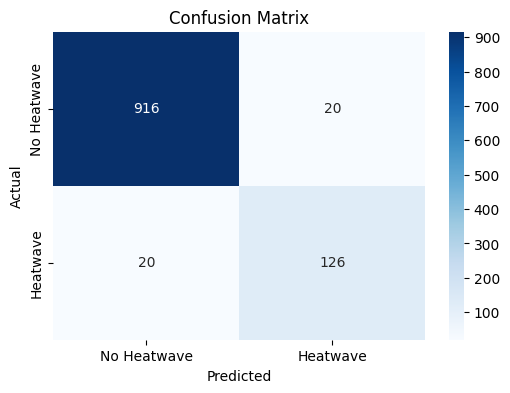

Prediction step: 2

Precision: 0.76
Recall:    0.76
F1 Score:  0.76


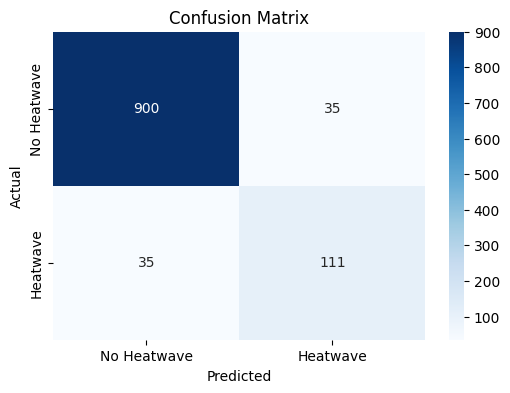

Prediction step: 3

Precision: 0.61
Recall:    0.75
F1 Score:  0.67


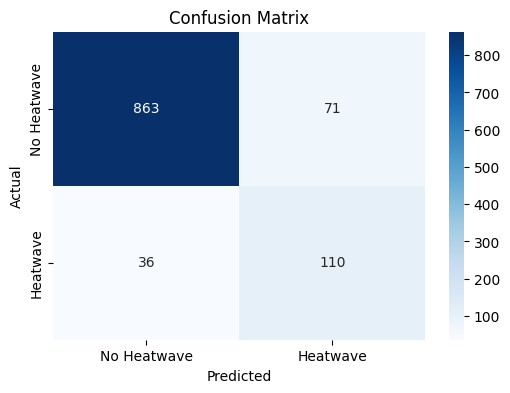

Prediction step: 4

Precision: 0.56
Recall:    0.77
F1 Score:  0.65


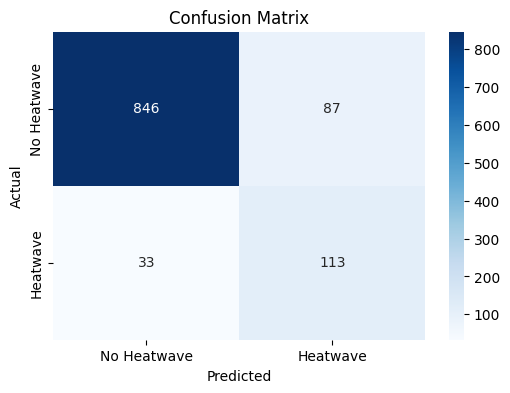

In [31]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set threshold based on 90th percentile of historical daily max temperatures
threshold = np.percentile(daily_max_temp["temp_c"], 90)

# Function to classify heatwave: 3 consecutive days above threshold
def classify_heatwave(data, threshold):
    # Convert to NumPy array if needed
    if isinstance(data, (pd.DataFrame, pd.Series)):
        data = data.values.flatten()
    heatwave = [0] * len(data)
    for i in range(2, len(data)):
        if data[i] >= threshold and data[i-1] >= threshold and data[i-2] >= threshold:
            heatwave[i] = 1
            heatwave[i-1] = 1
            heatwave[i-2] = 1
    return heatwave

# Rescale y_test (if needed)
y_test_rescaled = scaler.inverse_transform(y_test)
actual_values = pd.DataFrame(y_test_rescaled, columns=['temp_c'])  # Make sure to label columns

# Initialize lists to store metrics
all_Precision = []
all_recall = []
all_f1score = []

# Loop through prediction_dict (step-ahead forecasts)
for step in range(1, len(predection) + 1):
    print(f"Prediction step: {step}\n")

    # Fix the shape of prediction data
    prediction_array = np.array(predection[step]).reshape(-1, 1)
    prediction = pd.DataFrame(prediction_array, columns=['temp_c'])

    # Slice actual values to align with prediction length
    temperory_actual_values = actual_values.iloc[step - 1: step - 1 + len(prediction)].copy()

    # Classify heatwaves
    actual_flags = classify_heatwave(temperory_actual_values['temp_c'], threshold)
    pred_flags = classify_heatwave(prediction['temp_c'], threshold)

    temperory_actual_values["day_included_heatwave"] = actual_flags
    prediction["day_included_heatwave"] = pred_flags

    # Evaluation
    y_true = temperory_actual_values['day_included_heatwave']
    y_pred = prediction['day_included_heatwave']

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    all_Precision.append(precision)
    all_recall.append(recall)
    all_f1score.append(f1)

    print(f'Precision: {precision:.2f}')
    print(f'Recall:    {recall:.2f}')
    print(f'F1 Score:  {f1:.2f}')

    # Confusion matrix
    conf_matrix = confusion_matrix(y_true, y_pred)

    # Plot
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Heatwave', 'Heatwave'],
                yticklabels=['No Heatwave', 'Heatwave'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# try sequance 3

data X train shape: (4323, 3, 1),data X test shape: (1081, 3, 1)
data y train shape: (4323, 1),data y test shape: (1081, 1)
Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 3)
Epoch 10/300, Loss: 0.1744
Epoch 20/300, Loss: 0.1713
Epoch 30/300, Loss: 0.1570
Epoch 40/300, Loss: 0.0841
Epoch 50/300, Loss: 0.0394
Epoch 60/300, Loss: 0.0260
Epoch 70/300, Loss: 0.0200
Epoch 80/300, Loss: 0.0191
Epoch 90/300, Loss: 0.0182
Epoch 100/300, Loss: 0.0175
Epoch 110/300, Loss: 0.0168
Epoch 120/300, Loss: 0.0162
Epoch 130/300, Loss: 0.0156
Epoch 140/300, Loss: 0.0150
Epoch 150/300, Loss: 0.0143
Epoch 160/300, Loss: 0.0137
Epoch 170/300, Loss: 0.0131
Epoch 180/300, Loss: 0.0126
Epoch 190/300, Loss: 0.0121
Epoch 200/300, Loss: 0.0117
Epoch 210/300, Loss: 0.0115
Epoch 220/300, Loss: 0.0113
Epoch 230/300, Loss: 0.0113
Epoch 240/300, Loss: 0.0113
Epoch 250/300, Loss: 0.0112
Epoch 260/300, Loss: 0.0112
Epoch 270/300, Loss: 0.0112
Epoch 280/300, Loss: 0.0112
Epoch 290/

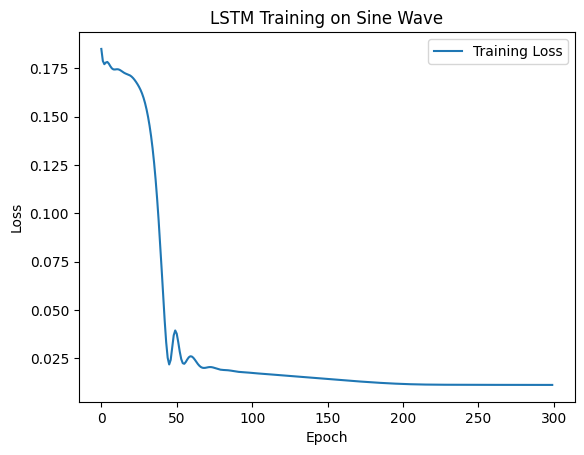

x test len:1081



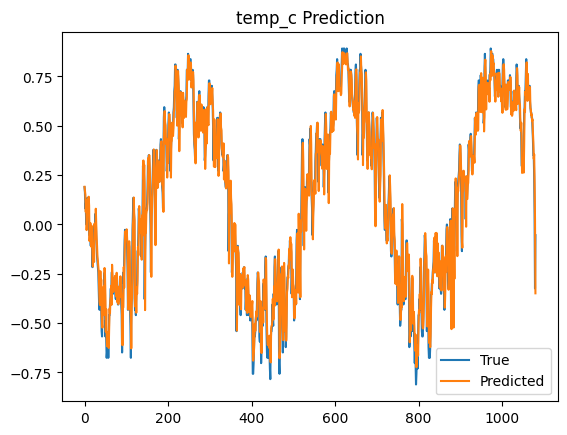

y test len:1081

y predicted len:1081

y orignal test len:1081

y orignal predicted len:1081



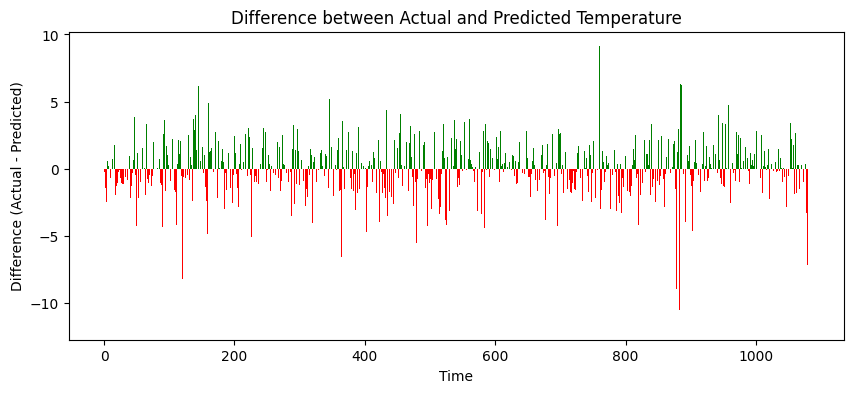

R² Score: 0.9506
Mean Squared Error (MSE): 4.1350
Mean Absolute Error (MAE): 1.4822
Root Mean Squared Error (RMSE): 2.0335


In [12]:
data=daily_max_temp['temp_c'].values.reshape(-1,1)
data,scaler=normalize_data(data)
# Create sequences for training/testing
def create_sequences(data, sequence_length):
    sequences, labels = [], []
    for i in range(len(data) - sequence_length):
        sequences.append(data[i:i + sequence_length])
        labels.append(data[i + sequence_length])
    return np.array(sequences), np.array(labels)
# Initialize variables
sequence_length =3
# Make a copy of the original DataFrame to update
updated_data = data.copy()

X, y = create_sequences(updated_data, sequence_length)

# Train-test split
train_size = int(len(X) * 0.8)
X_train_3, X_test_3 = X[:train_size], X[train_size:]
y_train_3, y_test_3 = y[:train_size], y[train_size:]
print(f"data X train shape: {X_train_3.shape},data X test shape: {X_test_3.shape}")
print(f"data y train shape: {y_train_3.shape},data y test shape: {y_test_3.shape}")
# Convert to tensors
X_train_tensor_3 = torch.tensor(X_train_3, dtype=torch.float32)
y_train_tensor_3 = torch.tensor(y_train_3, dtype=torch.float32).view(-1, 1)
X_test_tensor_3 = torch.tensor(X_test_3, dtype=torch.float32)
y_test_tensor_3 = torch.tensor(y_test_3, dtype=torch.float32).view(-1, 1)
 # Define LSTM model
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_qubits=0,n_qlayers=1, backend='default.qubit'):
        super(LSTMRegressor, self).__init__()
        self.hidden_dim = hidden_dim
        
        if n_qubits > 0:
            print(f"Using Quantum LSTM on backend {backend}")
            self.lstm = QLSTM(input_dim, hidden_dim, n_qubits=n_qubits,n_qlayers=n_qlayers ,backend=backend)
        else:
            print("Using Classical LSTM")
            self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x.view(x.shape[0], x.shape[1], -1))
        output = self.fc(lstm_out[:, -1])  # Predict next value
        return output
 # Model parameters
Qinput_dim = 1
Qhidden_dim = 16
Qn_qubits = 3
backend = 'default.qubit' 
model = LSTMRegressor(Qinput_dim, Qhidden_dim, n_qubits=Qn_qubits, backend=backend)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_function = nn.MSELoss()

# Training loop
num_epochs = 300
loss_history = []
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor_3)
    loss = loss_function(outputs, y_train_tensor_3)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training on Sine Wave')
plt.legend()
plt.show()
print(f'x test len:{len(X_test_tensor_3)}\n')
# Predict and visualize
model.eval()
y_pred_3 = model(X_test_tensor_3).detach().numpy()
plt.plot(range(len(y_test_3)), y_test_3, label='True')
plt.plot(range(len(y_test_3)), y_pred_3, label='Predicted')
plt.legend()
plt.title('temp_c Prediction')
plt.show()

print(f'y test len:{len(y_test_3)}\n')
print(f'y predicted len:{len(y_pred_3)}\n')

# Apply inverse scaling to bring data back to its original scale
y_test_original_3 = scaler.inverse_transform(y_test_3)
y_pred_original_3 = scaler.inverse_transform(y_pred_3)

print(f'y orignal test len:{len(y_test_original_3)}\n')
print(f'y orignal predicted len:{len(y_pred_original_3)}\n')

# Calculate the differences
diff = y_test_original_3 - y_pred_original_3

plt.figure(figsize=(10, 4))

# Use colors to indicate positive and negative differences
colors = np.where(diff >= 0, "green", "red")

for i in range(len(diff)):
    plt.bar(i, diff[i], color=colors[i])

plt.xlabel("Time")
plt.ylabel("Difference (Actual - Predicted)")
plt.title("Difference between Actual and Predicted Temperature")
plt.show()

r2 = r2_score(y_test_original_3, y_pred_original_3)
mse = mean_squared_error(y_test_original_3, y_pred_original_3)
mae = mean_absolute_error(y_test_original_3, y_pred_original_3)
rmse = np.sqrt(mse)

# Print results
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

In [32]:
predection_3=iterative_forecast_map(model,X_test_tensor_3,4,scaler)

C:\Users\muham\AppData\Local\Temp\ipykernel_21124\1708310602.py:77: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tensor(sequence[np.newaxis, :, :], dtype=torch.float32)
C:\Users\muham\AppData\Local\Temp\ipykernel_21124\1708310602.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tensor(sequence[np.newaxis, :, :], dtype=torch.float32)  # Add batch dimension
C:\Users\muham\AppData\Local\Temp\ipykernel_21124\1708310602.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tens

Prediction step: 1

Precision: 0.92
Recall:    0.75
F1 Score:  0.83


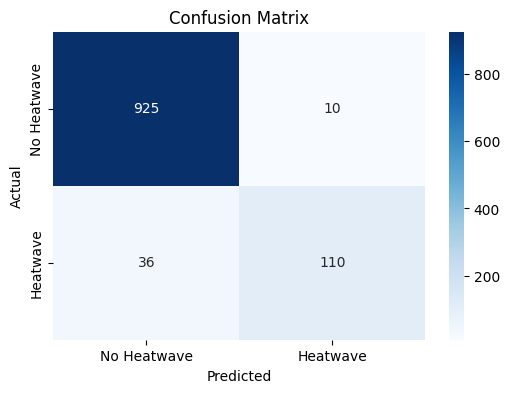

Prediction step: 2

Precision: 0.85
Recall:    0.49
F1 Score:  0.62


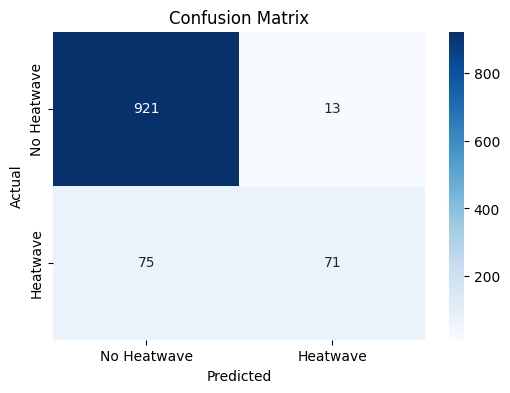

Prediction step: 3

Precision: 0.78
Recall:    0.40
F1 Score:  0.53


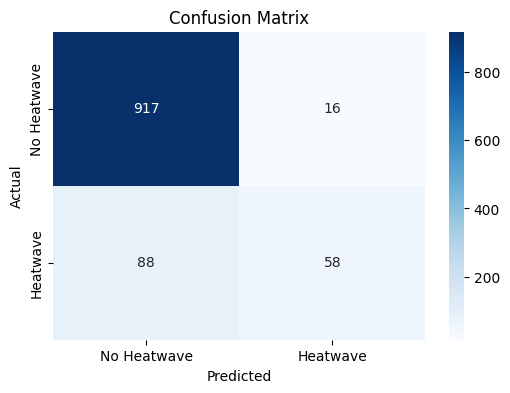

Prediction step: 4

Precision: 0.82
Recall:    0.32
F1 Score:  0.46


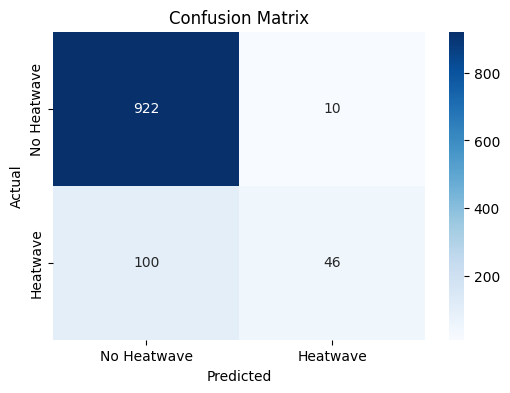

In [34]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set threshold based on 90th percentile of historical daily max temperatures
threshold = np.percentile(daily_max_temp["temp_c"], 90)

# Function to classify heatwave: 3 consecutive days above threshold
def classify_heatwave(data, threshold):
    # Convert to NumPy array if needed
    if isinstance(data, (pd.DataFrame, pd.Series)):
        data = data.values.flatten()
    heatwave = [0] * len(data)
    for i in range(2, len(data)):
        if data[i] >= threshold and data[i-1] >= threshold and data[i-2] >= threshold:
            heatwave[i] = 1
            heatwave[i-1] = 1
            heatwave[i-2] = 1
    return heatwave

# Rescale y_test (if needed)
y_test_rescaled = scaler.inverse_transform(y_test_3)
actual_values = pd.DataFrame(y_test_rescaled, columns=['temp_c'])  # Make sure to label columns

# Initialize lists to store metrics
all_Precision = []
all_recall = []
all_f1score = []

# Loop through prediction_dict (step-ahead forecasts)
for step in range(1, len(predection) + 1):
    print(f"Prediction step: {step}\n")

    # Fix the shape of prediction data
    prediction_array = np.array(predection_3[step]).reshape(-1, 1)
    prediction = pd.DataFrame(prediction_array, columns=['temp_c'])

    # Slice actual values to align with prediction length
    temperory_actual_values = actual_values.iloc[step - 1: step - 1 + len(prediction)].copy()

    # Classify heatwaves
    actual_flags = classify_heatwave(temperory_actual_values['temp_c'], threshold)
    pred_flags = classify_heatwave(prediction['temp_c'], threshold)

    temperory_actual_values["day_included_heatwave"] = actual_flags
    prediction["day_included_heatwave"] = pred_flags

    # Evaluation
    y_true = temperory_actual_values['day_included_heatwave']
    y_pred = prediction['day_included_heatwave']

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    all_Precision.append(precision)
    all_recall.append(recall)
    all_f1score.append(f1)

    print(f'Precision: {precision:.2f}')
    print(f'Recall:    {recall:.2f}')
    print(f'F1 Score:  {f1:.2f}')

    # Confusion matrix
    conf_matrix = confusion_matrix(y_true, y_pred)

    # Plot
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Heatwave', 'Heatwave'],
                yticklabels=['No Heatwave', 'Heatwave'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# try seq 7 predict 3

Number of sequences: 5398
X_train_7_3 shape: (4318, 7, 1), X_test_7_3 shape: (1080, 7, 1)
y_train_7_3 shape: (4318, 3, 1), y_test_7_3 shape: (1080, 3, 1)
Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 3)
Epoch 10/300, Loss: 0.0484
Epoch 20/300, Loss: 0.0513
Epoch 30/300, Loss: 0.0441
Epoch 40/300, Loss: 0.0444
Epoch 50/300, Loss: 0.0434
Epoch 60/300, Loss: 0.0429
Epoch 70/300, Loss: 0.0417
Epoch 80/300, Loss: 0.0389
Epoch 90/300, Loss: 0.0317
Epoch 100/300, Loss: 0.0166
Epoch 110/300, Loss: 0.0097
Epoch 120/300, Loss: 0.0077
Epoch 130/300, Loss: 0.0075
Epoch 140/300, Loss: 0.0071
Epoch 150/300, Loss: 0.0068
Epoch 160/300, Loss: 0.0066
Epoch 170/300, Loss: 0.0066
Epoch 180/300, Loss: 0.0065
Epoch 190/300, Loss: 0.0064
Epoch 200/300, Loss: 0.0063
Epoch 210/300, Loss: 0.0063
Epoch 220/300, Loss: 0.0062
Epoch 230/300, Loss: 0.0061
Epoch 240/300, Loss: 0.0061
Epoch 250/300, Loss: 0.0060
Epoch 260/300, Loss: 0.0060
Epoch 270/300, Loss: 0.0059
Epoch 28

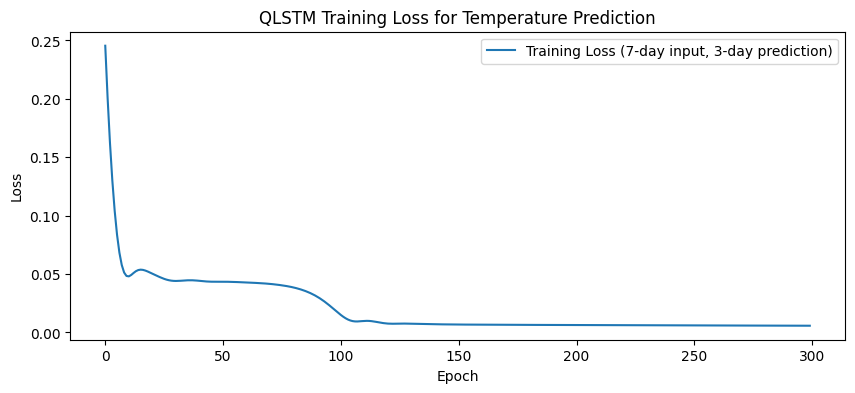

X_test_7_3 len: 1080
y_test_7_3 len: 1080
y_pred_3_days len: 1080
y_test_original_7_3 len: 1080
y_pred_original_3_days len: 1080


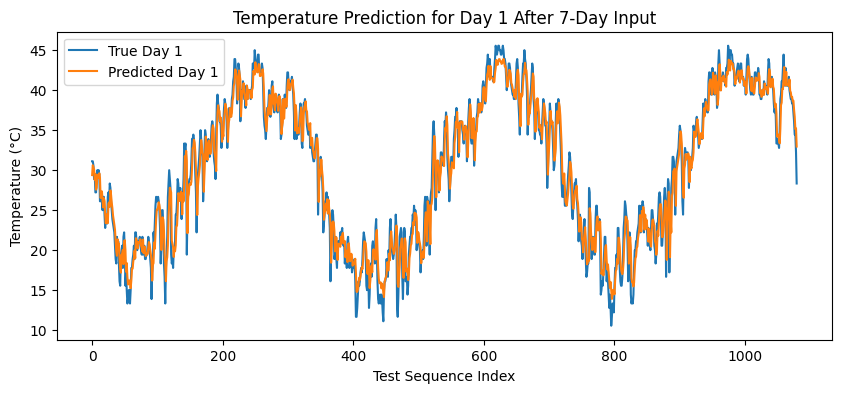

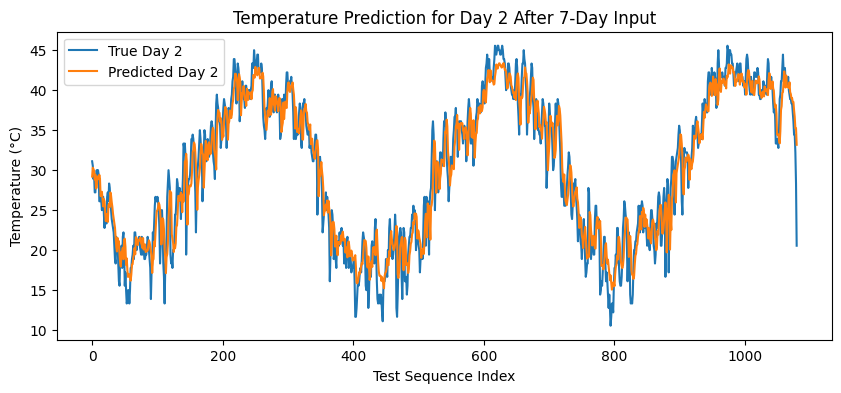

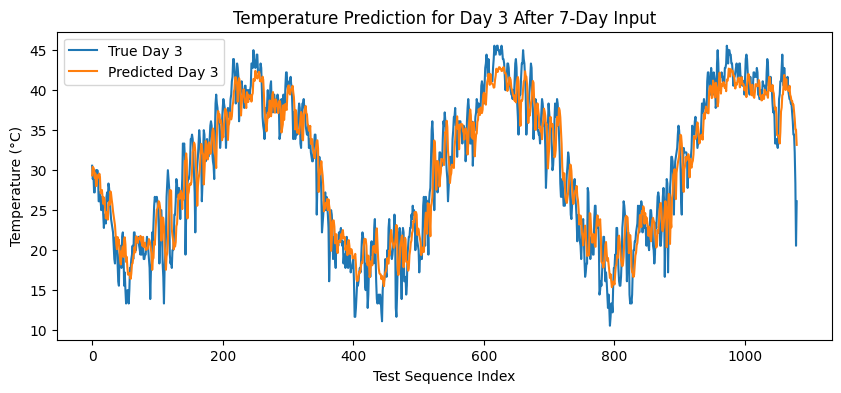

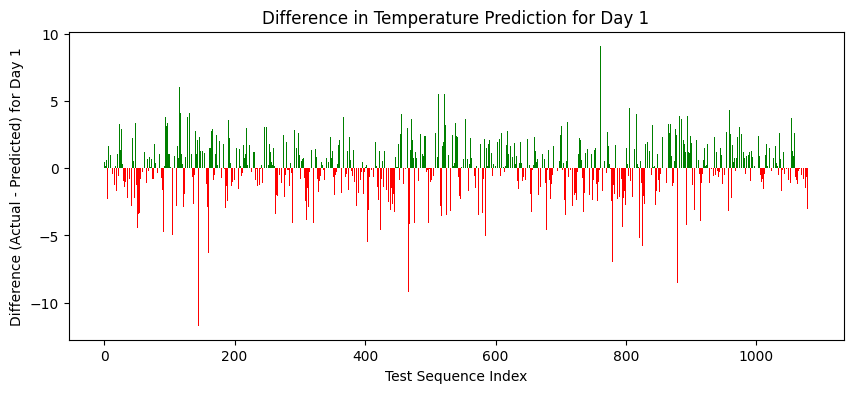

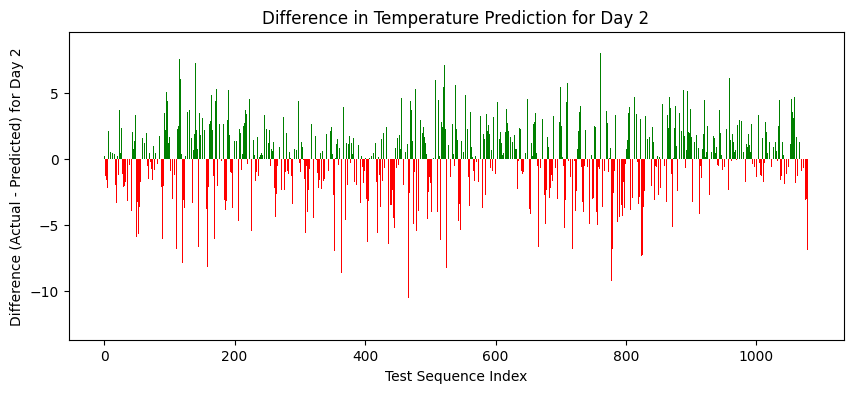

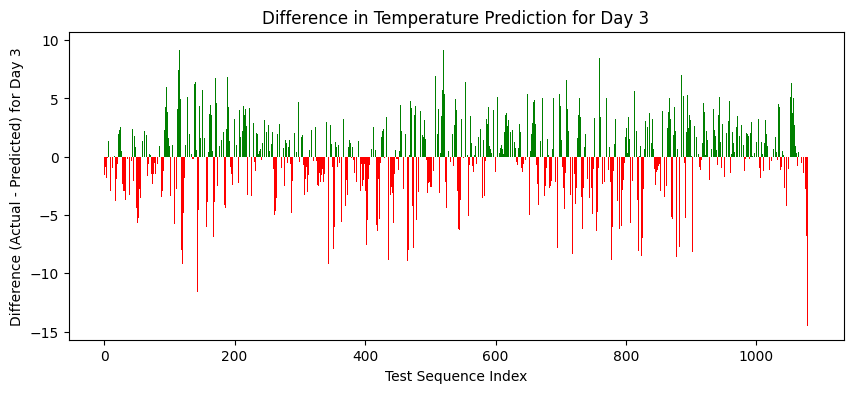


Metrics for Day 1 Prediction:
R² Score: 0.9482
Mean Squared Error (MSE): 4.3338
Mean Absolute Error (MAE): 1.5551
Root Mean Squared Error (RMSE): 2.0818

Metrics for Day 2 Prediction:
R² Score: 0.8960
Mean Squared Error (MSE): 8.7067
Mean Absolute Error (MAE): 2.2951
Root Mean Squared Error (RMSE): 2.9507

Metrics for Day 3 Prediction:
R² Score: 0.8605
Mean Squared Error (MSE): 11.6720
Mean Absolute Error (MAE): 2.6881
Root Mean Squared Error (RMSE): 3.4164


In [24]:
data = daily_max_temp['temp_c'].values.reshape(-1, 1)

# Normalize the data
def normalize_data(data):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    return scaled_data, scaler

data_normalized, scaler = normalize_data(data)

# Sequence creation for 7-day input and 3-day output
def create_sequences_7_3(data, input_seq_length=7, output_seq_length=3):
    sequences, labels = [], []
    for i in range(len(data) - input_seq_length - output_seq_length + 1):
        seq = data[i:i + input_seq_length]
        label = data[i + input_seq_length:i + input_seq_length + output_seq_length]
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

# Initialize variables
input_seq_length = 7
output_seq_length = 3

# Create sequences
X_7_3, y_7_3 = create_sequences_7_3(data_normalized, input_seq_length, output_seq_length)
print(f"Number of sequences: {len(X_7_3)}")  # Should be 1 for 10 values

# For small dataset, use all for training (or adjust for larger dataset)
train_size_7_3 = int(len(X_7_3) * 0.8) or 1  # Ensure at least 1 sequence
X_train_7_3, X_test_7_3 = X_7_3[:train_size_7_3], X_7_3[train_size_7_3:]
y_train_7_3, y_test_7_3 = y_7_3[:train_size_7_3], y_7_3[train_size_7_3:]
print(f"X_train_7_3 shape: {X_train_7_3.shape}, X_test_7_3 shape: {X_test_7_3.shape}")
print(f"y_train_7_3 shape: {y_train_7_3.shape}, y_test_7_3 shape: {y_test_7_3.shape}")

# Convert to tensors
X_train_tensor_7_3 = torch.tensor(X_train_7_3, dtype=torch.float32)
y_train_tensor_7_3 = torch.tensor(y_train_7_3, dtype=torch.float32).squeeze(-1)  # Shape: (n, 3)
X_test_tensor_7_3 = torch.tensor(X_test_7_3, dtype=torch.float32)
y_test_tensor_7_3 = torch.tensor(y_test_7_3, dtype=torch.float32).squeeze(-1)  # Shape: (m, 3)

# Updated LSTMRegressor for 3-day prediction
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_qubits=0, n_qlayers=1, backend='default.qubit'):
        super(LSTMRegressor, self).__init__()
        self.hidden_dim = hidden_dim
        if n_qubits > 0:
            print(f"Using Quantum LSTM on backend {backend}")
            self.lstm = QLSTM(input_dim, hidden_dim, n_qubits=n_qubits, n_qlayers=n_qlayers, backend=backend)
        else:
            print("Using Classical LSTM")
            self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 3)  # Output 3 values for 3-day prediction

    def forward(self, x):
        lstm_out, _ = self.lstm(x.view(x.shape[0], x.shape[1], -1))
        output = self.fc(lstm_out[:, -1])  # Predict 3 days from last hidden state
        return output

# Model parameters
Qinput_dim = 1
Qhidden_dim = 16
Qn_qubits = 3
backend = 'default.qubit'
model_7_3 = LSTMRegressor(Qinput_dim, Qhidden_dim, n_qubits=Qn_qubits, backend=backend)
optimizer = optim.Adam(model_7_3.parameters(), lr=0.01)
loss_function = nn.MSELoss()

# Training loop
num_epochs = 300
loss_history_7_3 = []
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs_7_3 = model_7_3(X_train_tensor_7_3)  # Shape: (train_size, 3)
    loss = loss_function(outputs_7_3, y_train_tensor_7_3)
    loss.backward()
    optimizer.step()
    loss_history_7_3.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(loss_history_7_3, label='Training Loss (7-day input, 3-day prediction)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('QLSTM Training Loss for Temperature Prediction')
plt.legend()
plt.show()

# Predict and visualize
model_7_3.eval()
with torch.no_grad():
    y_pred_3_days = model_7_3(X_test_tensor_7_3).detach().numpy()  # Shape: (test_size, 3)

print(f"X_test_7_3 len: {len(X_test_tensor_7_3)}")
print(f"y_test_7_3 len: {len(y_test_7_3)}")
print(f"y_pred_3_days len: {len(y_pred_3_days)}")

# Apply inverse scaling
y_test_original_7_3 = scaler.inverse_transform(y_test_7_3.reshape(-1, 1)).reshape(len(y_test_7_3), 3)
y_pred_original_3_days = scaler.inverse_transform(y_pred_3_days.reshape(-1, 1)).reshape(len(y_pred_3_days), 3)

print(f"y_test_original_7_3 len: {len(y_test_original_7_3)}")
print(f"y_pred_original_3_days len: {len(y_pred_original_3_days)}")

# Plot actual vs predicted for each day
for day in range(3):
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_original_7_3[:, day], label=f'True Day {day+1}')
    plt.plot(y_pred_original_3_days[:, day], label=f'Predicted Day {day+1}')
    plt.xlabel('Test Sequence Index')
    plt.ylabel('Temperature (°C)')
    plt.title(f'Temperature Prediction for Day {day+1} After 7-Day Input')
    plt.legend()
    plt.show()

# Calculate differences and plot
diff_3_days = y_test_original_7_3 - y_pred_original_3_days
for day in range(3):
    plt.figure(figsize=(10, 4))
    colors = np.where(diff_3_days[:, day] >= 0, 'green', 'red')
    for i in range(len(diff_3_days)):
        plt.bar(i, diff_3_days[i, day], color=colors[i])
    plt.xlabel('Test Sequence Index')
    plt.ylabel(f'Difference (Actual - Predicted) for Day {day+1}')
    plt.title(f'Difference in Temperature Prediction for Day {day+1}')
    plt.show()

# Calculate metrics for each day
for day in range(3):
    r2 = r2_score(y_test_original_7_3[:, day], y_pred_original_3_days[:, day])
    mse = mean_squared_error(y_test_original_7_3[:, day], y_pred_original_3_days[:, day])
    mae = mean_absolute_error(y_test_original_7_3[:, day], y_pred_original_3_days[:, day])
    rmse = np.sqrt(mse)
    print(f"\nMetrics for Day {day+1} Prediction:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# 8 dim qlstm

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pennylane as qml

# Define QLSTM model
class dim_8_QLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, n_qubits=4, n_qlayers=1,backend="default.qubit", batch_first=True):
        super(dim_8_QLSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.concat_size = self.input_size + self.hidden_size
        self.n_qubits = n_qubits
        self.n_qlayers = n_qlayers
        self.backend="default.qubit"
        self.batch_first = batch_first

        self.wires_forget = [f"wire_forget_{i}" for i in range(self.n_qubits)]
        self.wires_input = [f"wire_input_{i}" for i in range(self.n_qubits)]
        self.wires_update = [f"wire_update_{i}" for i in range(self.n_qubits)]
        self.wires_output = [f"wire_output_{i}" for i in range(self.n_qubits)]

        self.dev_forget = qml.device(backend, wires=self.wires_forget)
        self.dev_input = qml.device(backend, wires=self.wires_input)
        self.dev_update = qml.device(backend, wires=self.wires_update)
        self.dev_output = qml.device(backend, wires=self.wires_output)

        def _circuit_forget(inputs, weights):
            qml.templates.AngleEmbedding(inputs, wires=self.wires_forget)
            qml.templates.BasicEntanglerLayers(weights, wires=self.wires_forget)
            return [qml.expval(qml.PauliZ(wires=w)) for w in self.wires_forget]
        self.qlayer_forget = qml.QNode(_circuit_forget, self.dev_forget, interface="torch")

        def _circuit_input(inputs, weights):
            qml.templates.AngleEmbedding(inputs, wires=self.wires_input)
            qml.templates.BasicEntanglerLayers(weights, wires=self.wires_input)
            return [qml.expval(qml.PauliZ(wires=w)) for w in self.wires_input]
        self.qlayer_input = qml.QNode(_circuit_input, self.dev_input, interface="torch")

        def _circuit_update(inputs, weights):
            qml.templates.AngleEmbedding(inputs, wires=self.wires_update)
            qml.templates.BasicEntanglerLayers(weights, wires=self.wires_update)
            return [qml.expval(qml.PauliZ(wires=w)) for w in self.wires_update]
        self.qlayer_update = qml.QNode(_circuit_update, self.dev_update, interface="torch")

        def _circuit_output(inputs, weights):
            qml.templates.AngleEmbedding(inputs, wires=self.wires_output)
            qml.templates.BasicEntanglerLayers(weights, wires=self.wires_output)
            return [qml.expval(qml.PauliZ(wires=w)) for w in self.wires_output]
        self.qlayer_output = qml.QNode(_circuit_output, self.dev_output, interface="torch")

        weight_shapes = {"weights": (n_qlayers, n_qubits)}
        print(f"weight_shapes = (n_qlayers, n_qubits) = ({n_qlayers}, {n_qubits})")

        self.clayer_in = torch.nn.Linear(self.concat_size, n_qubits)
        self.VQC = {
            'forget': qml.qnn.TorchLayer(self.qlayer_forget, weight_shapes),
            'input': qml.qnn.TorchLayer(self.qlayer_input, weight_shapes),
            'update': qml.qnn.TorchLayer(self.qlayer_update, weight_shapes),
            'output': qml.qnn.TorchLayer(self.qlayer_output, weight_shapes)
        }
        self.clayer_out = torch.nn.Linear(n_qubits, hidden_size)

    def forward(self, x, init_states=None):
        if self.batch_first:
            batch_size, seq_length, _ = x.size()
        else:
            seq_length, batch_size, _ = x.size()

        hidden_seq = []
        if init_states is None:
            h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
            c_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        else:
            h_t, c_t = init_states

        for t in range(seq_length):
            x_t = x[:, t, :]
            v_t = torch.cat((h_t, x_t), dim=1)
            y_t = self.clayer_in(v_t)

            f_t = torch.sigmoid(self.clayer_out(self.VQC['forget'](y_t)))
            i_t = torch.sigmoid(self.clayer_out(self.VQC['input'](y_t)))
            g_t = torch.tanh(self.clayer_out(self.VQC['update'](y_t)))
            o_t = torch.sigmoid(self.clayer_out(self.VQC['output'](y_t)))

            c_t = f_t * c_t + i_t * g_t
            h_t = o_t * torch.tanh(c_t)

            hidden_seq.append(h_t.unsqueeze(0))

        hidden_seq = torch.cat(hidden_seq, dim=0).transpose(0, 1).contiguous()
        return hidden_seq, (h_t, c_t)

# 8 dimintion  data seq len 3

X_train_tensor shape: torch.Size([4318, 7, 8])
y_train_tensor shape: torch.Size([4318, 3, 8])
X_test_tensor shape: torch.Size([1080, 7, 8])
y_test_tensor shape: torch.Size([1080, 3, 8])
weight_shapes = (n_qlayers, n_qubits) = (1, 8)
Epoch 10/100, Loss: 0.0672
Epoch 20/100, Loss: 0.0330
Epoch 30/100, Loss: 0.0286
Epoch 40/100, Loss: 0.0281
Epoch 50/100, Loss: 0.0274
Epoch 60/100, Loss: 0.0272
Epoch 70/100, Loss: 0.0269
Epoch 80/100, Loss: 0.0265
Epoch 90/100, Loss: 0.0254
Epoch 100/100, Loss: 0.0228


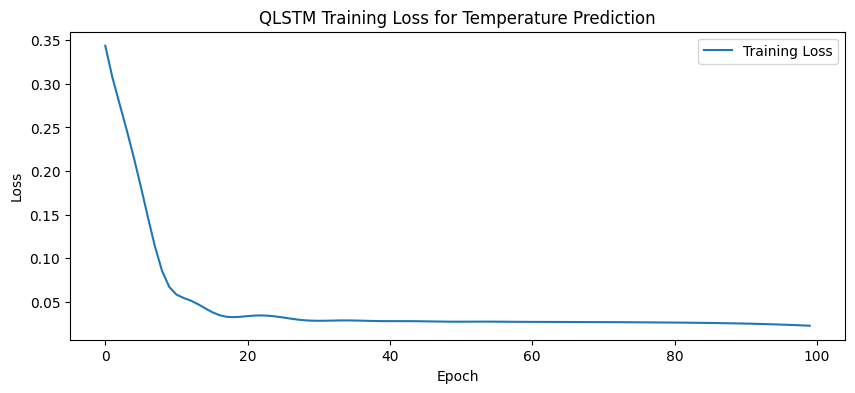

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Your QLSTM import and definition here (assumed defined)
# from your_module import dim_8_QLSTM

# Wrapper full model for output mapping
class FullModel(nn.Module):
    def __init__(self, qlstm, output_days):
        super().__init__()
        self.qlstm = qlstm
        self.fc_out = nn.Linear(qlstm.hidden_size, output_days * qlstm.input_size)  
        # we'll reshape output later to (batch, output_days, input_size)

    def forward(self, x):
        hidden_seq, _ = self.qlstm(x)  # shape (batch, seq_len, hidden_size)
        last_hidden = hidden_seq[:, -1, :]  # take last hidden, shape (batch, hidden_size)
        out = self.fc_out(last_hidden)  # shape (batch, output_days * input_size)
        out = out.view(-1, output_days, x.shape[2])  # reshape to (batch, output_days, num_features)
        return out

# ==== Data preprocessing ====

# Assume daily_max_temp is your original DataFrame with shape (num_days, 8 features)
# For example, if daily_max_temp is loaded from somewhere:
# daily_max_temp = pd.read_csv('your_data.csv')  # should have 8 feature columns

data = daily_max_temp.values  # shape (num_days, 8)

scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(data)  # shape (num_days, 8)

# Sequence creation function: input_seq_length=7, output_seq_length=3
def create_sequences_7_3_8_dim(data, input_seq_length=7, output_seq_length=3):
    sequences, labels = [], []
    for i in range(len(data) - input_seq_length - output_seq_length + 1):
        seq = data[i:i + input_seq_length]  # (7, 8)
        label = data[i + input_seq_length:i + input_seq_length + output_seq_length]  # (3, 8)
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

input_days = 7
output_days = 3

X_seq, y_seq = create_sequences_7_3_8_dim(normalized_data, input_days, output_days)

split_idx = int(len(X_seq) * 0.8)
X_train = X_seq[:split_idx]  # shape (N_train, 7, 8)
y_train = y_seq[:split_idx]  # shape (N_train, 3, 8)
X_test = X_seq[split_idx:]   # shape (N_test, 7, 8)
y_test = y_seq[split_idx:]   # shape (N_test, 3, 8)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)  # Expected: (N_train, 7, 8)
print("y_train_tensor shape:", y_train_tensor.shape)  # Expected: (N_train, 3, 8)
print("X_test_tensor shape:", X_test_tensor.shape)    # Expected: (N_test, 7, 8)
print("y_test_tensor shape:", y_test_tensor.shape)    # Expected: (N_test, 3, 8)

# ==== Model instantiation ====

input_size = X_train_tensor.shape[2]  # should be 8
hidden_size = 24
n_qubits = 8
n_qlayers = 1

qlstm_model = dim_8_QLSTM(input_size=input_size, hidden_size=hidden_size, n_qubits=n_qubits, n_qlayers=n_qlayers)
full_model = FullModel(qlstm_model, output_days)

optimizer = optim.Adam(full_model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# ==== Training loop ====

num_epochs = 100
loss_history = []

full_model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    preds = full_model(X_train_tensor)  # shape (N_train, 3, 8)
    loss = loss_fn(preds, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# ==== Plot training loss ====

plt.figure(figsize=(10, 4))
plt.plot(loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('QLSTM Training Loss for Temperature Prediction')
plt.legend()
plt.show()


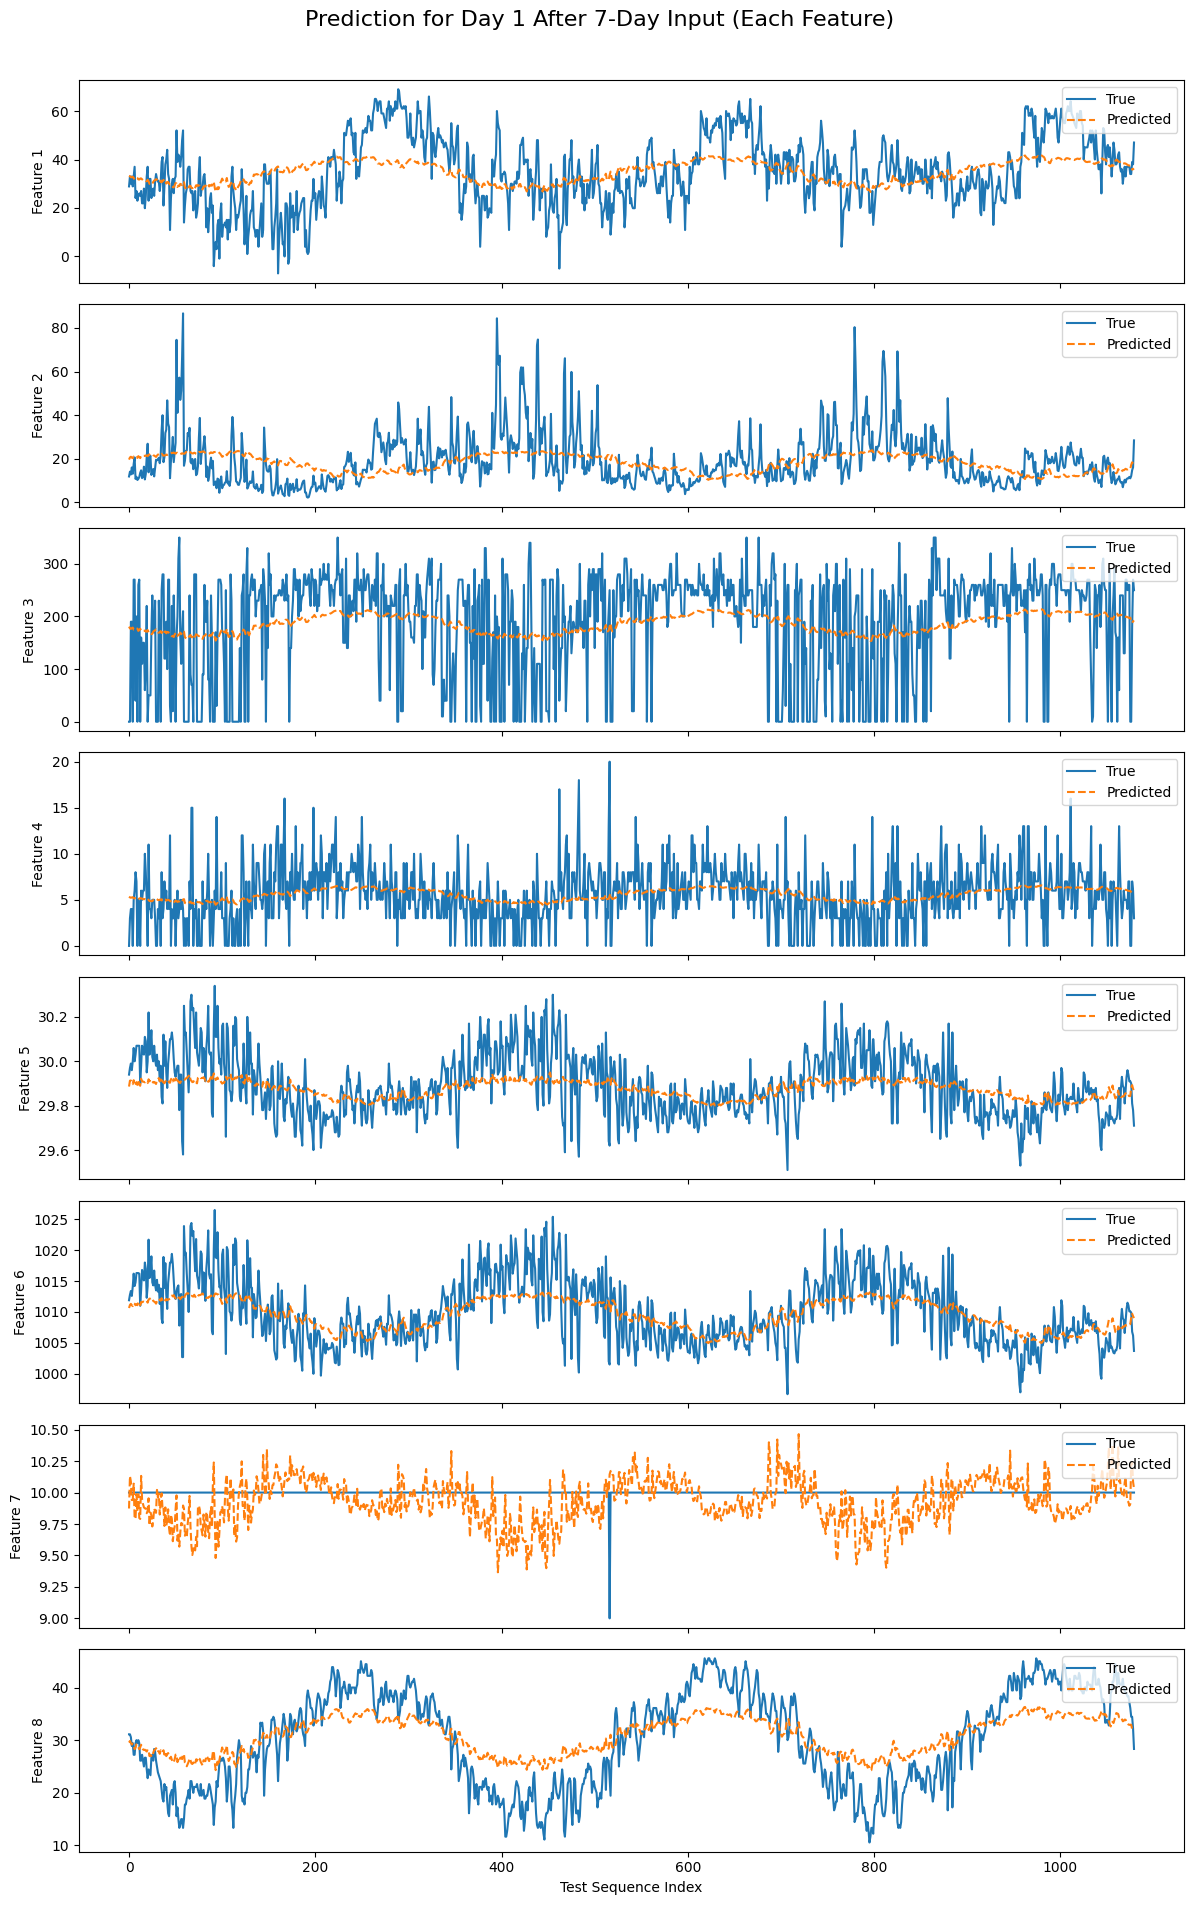

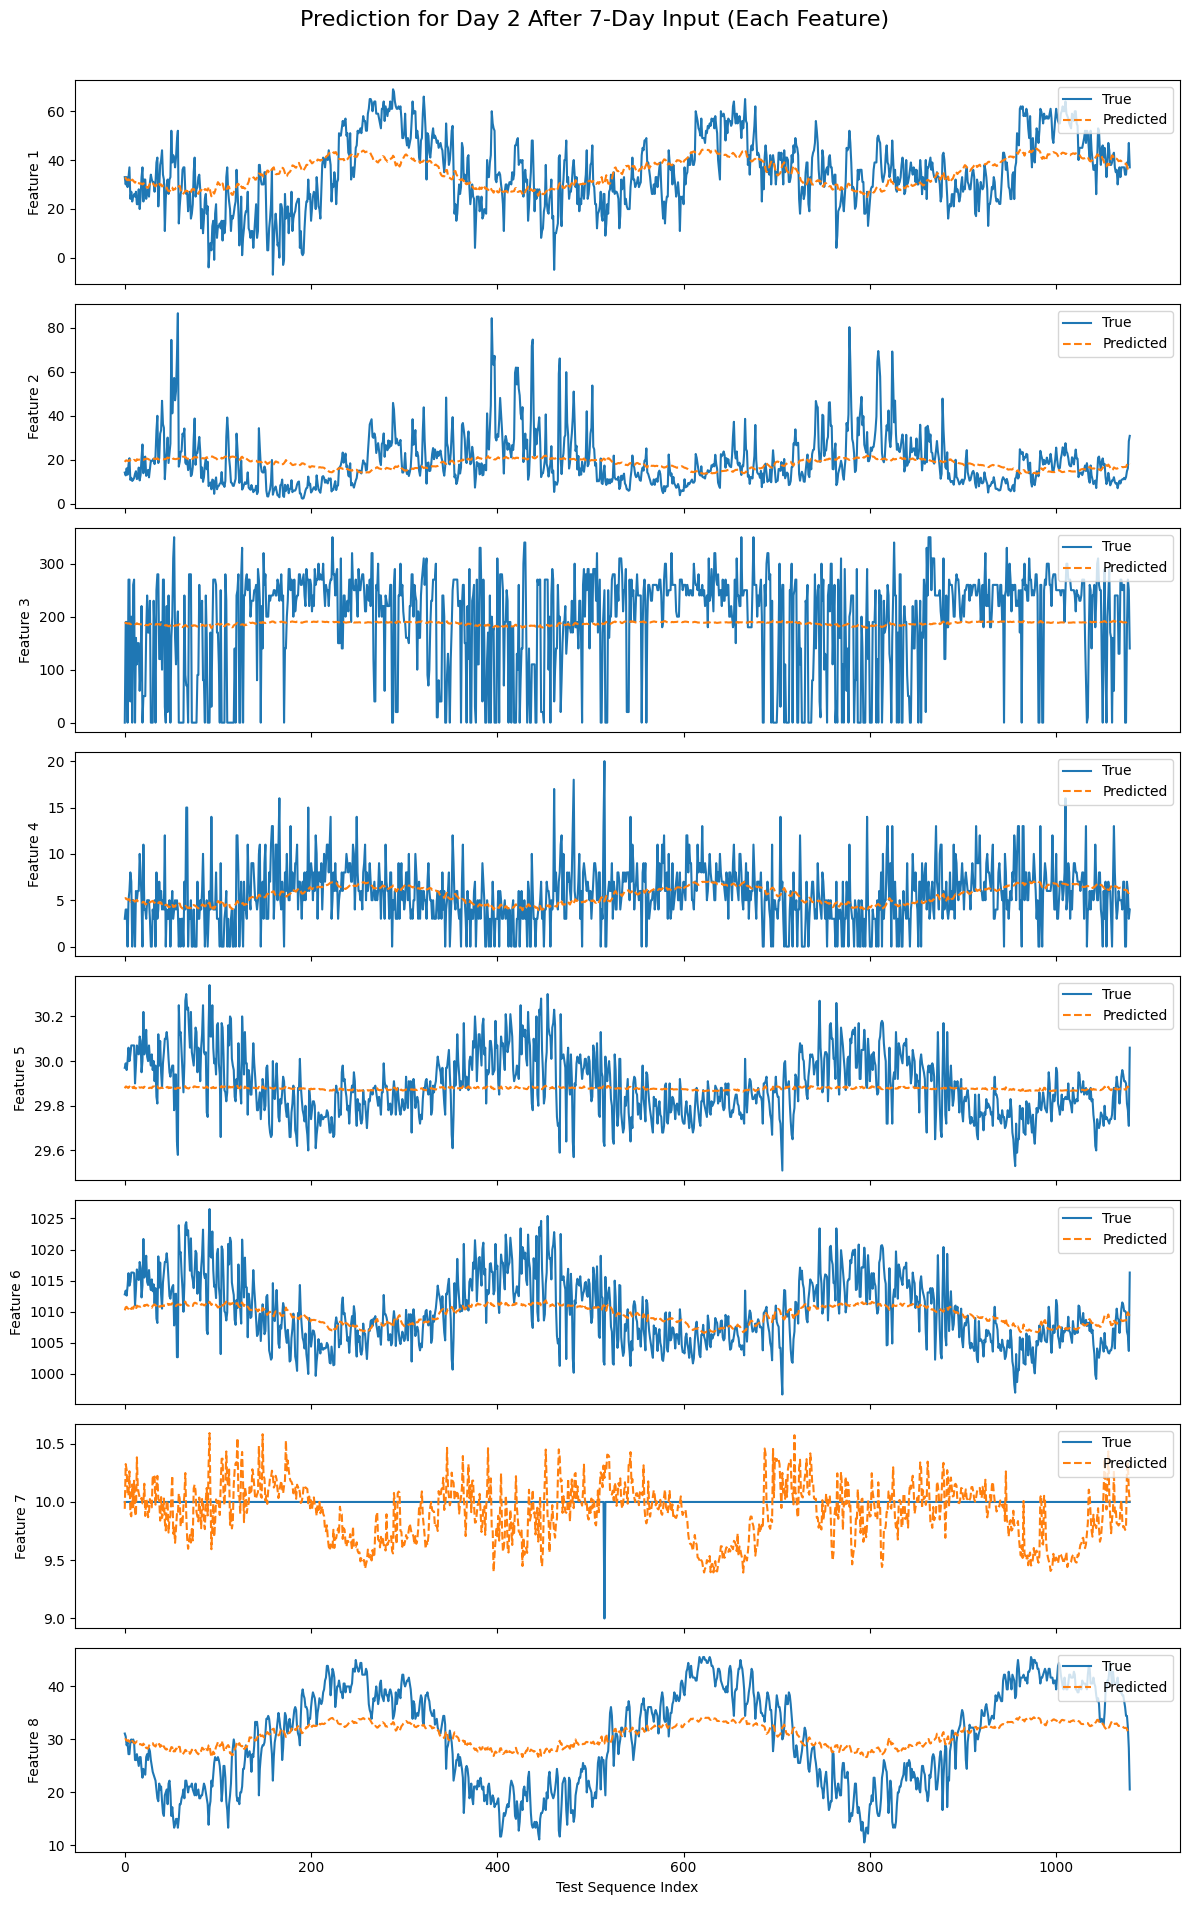

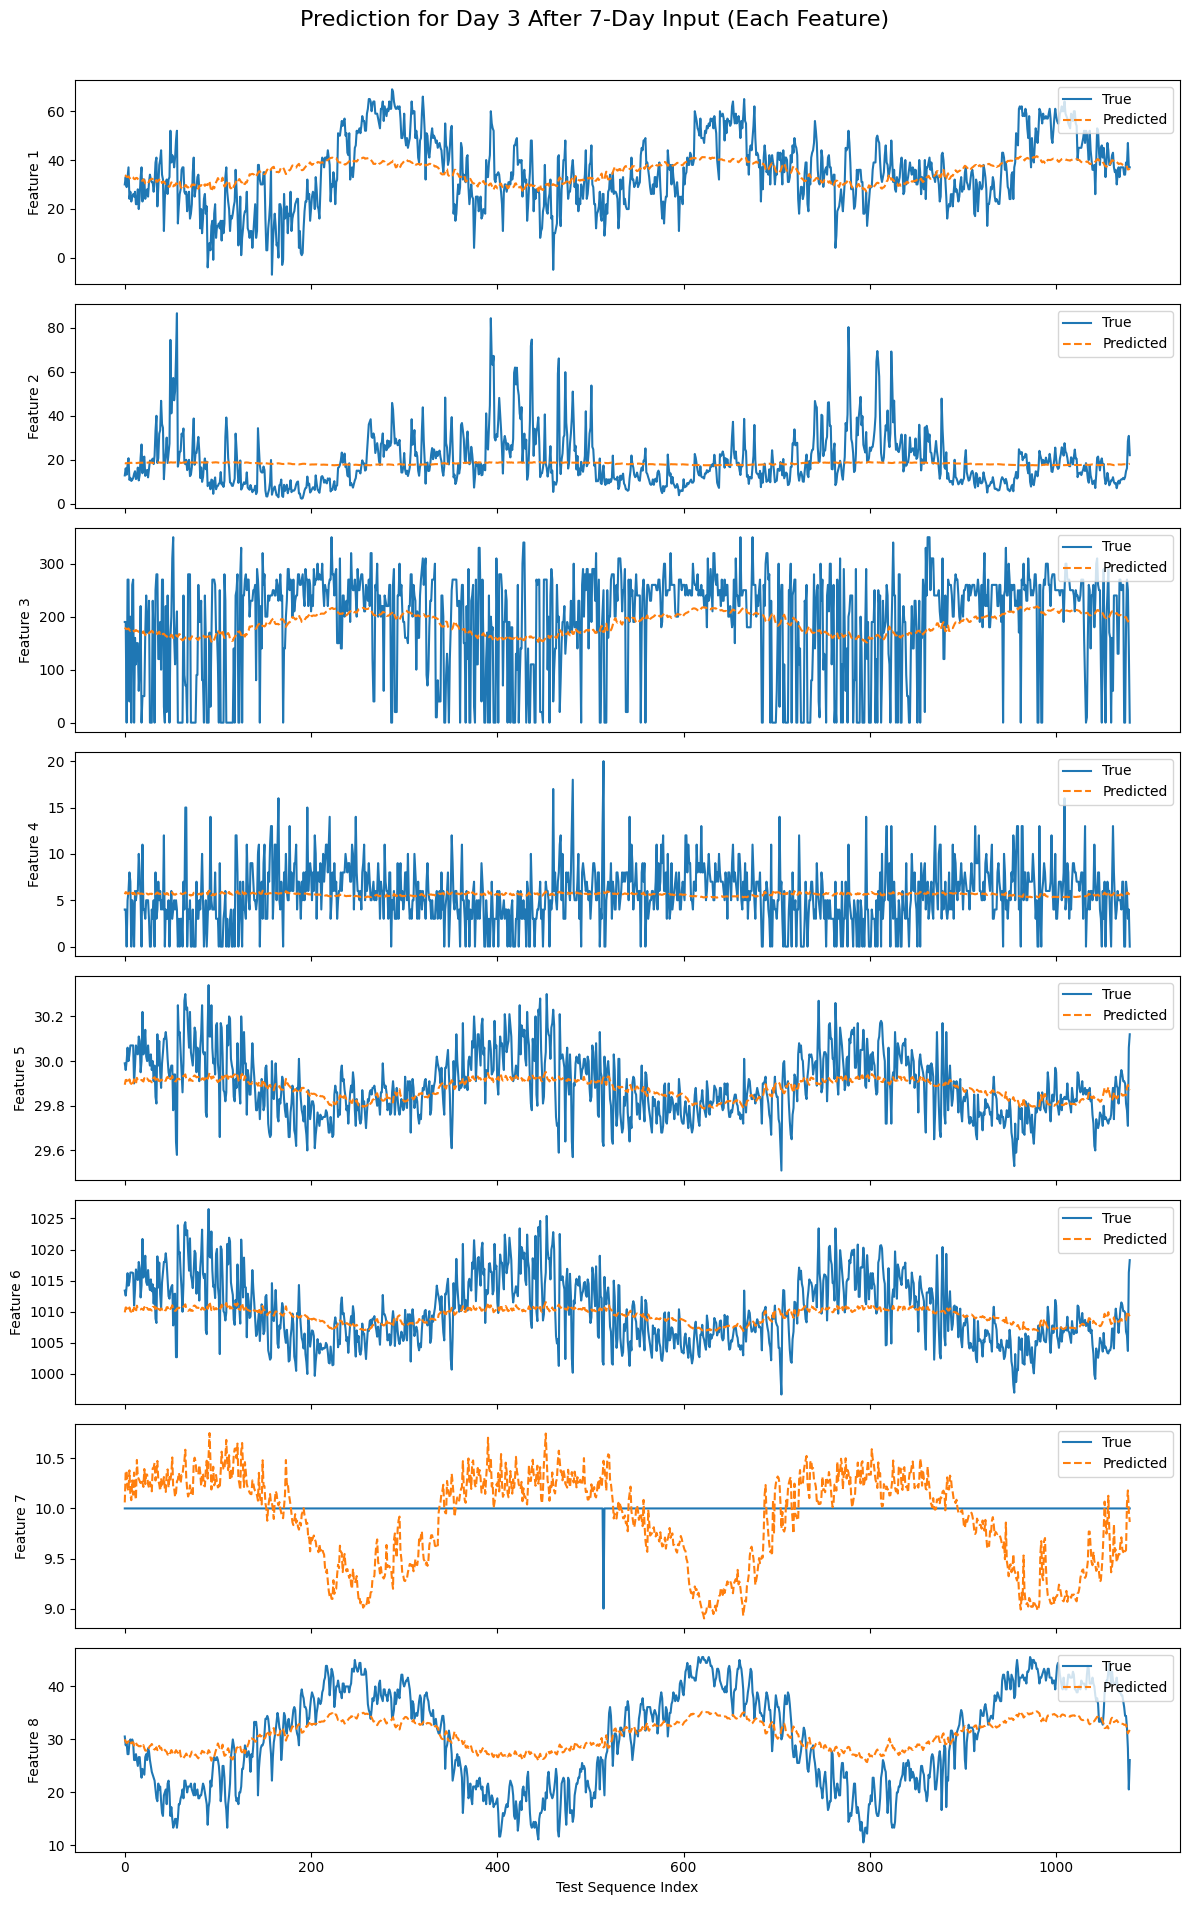

Metrics for Day 1:


TypeError: got an unexpected keyword argument 'squared'

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ==== Evaluation ====

full_model.eval()
with torch.no_grad():
    y_pred = full_model(X_test_tensor).cpu().numpy()  # shape (N_test, 3, 8)

# Inverse scale
y_test_2d = y_test.reshape(-1, input_size)
y_pred_2d = y_pred.reshape(-1, input_size)

y_test_orig = scaler.inverse_transform(y_test_2d).reshape(y_test.shape)
y_pred_orig = scaler.inverse_transform(y_pred_2d).reshape(y_pred.shape)

# Plot actual vs predicted — one subplot per feature
for day in range(output_days):
    fig, axs = plt.subplots(nrows=input_size, ncols=1, figsize=(12, input_size * 2.5), sharex=True)
    fig.suptitle(f'Prediction for Day {day+1} After {input_days}-Day Input (Each Feature)', fontsize=16)

    for feature in range(input_size):
        ax = axs[feature]
        ax.plot(y_test_orig[:, day, feature], label='True', linestyle='-')
        ax.plot(y_pred_orig[:, day, feature], label='Predicted', linestyle='--')
        ax.set_ylabel(f'Feature {feature+1}')
        ax.legend(loc='upper right')

    axs[-1].set_xlabel('Test Sequence Index')
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

# Print metrics
for day in range(output_days):
    print(f"Metrics for Day {day+1}:")
    for feature in range(input_size):
        r2 = r2_score(y_test_orig[:, day, feature], y_pred_orig[:, day, feature])
        rmse = mean_squared_error(y_test_orig[:, day, feature], y_pred_orig[:, day, feature], squared=False)
        mae = mean_absolute_error(y_test_orig[:, day, feature], y_pred_orig[:, day, feature])
        print(f"  Feature {feature+1} - R2: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    print()


# 8 diminthion data sequances lenth 1 and 8 qubit

In [15]:
data = daily_max_temp.iloc[:, :8].values  # Extract first 8 columns as features
data

array([[  14.        ,   12.74      ,  184.99445061, ..., 1019.7       ,
          10.        ,   19.44444444],
       [  26.        ,   19.77      ,  310.        , ..., 1015.7       ,
          10.        ,   20.55555556],
       [  23.        ,   16.26      ,    0.        , ..., 1017.3       ,
          10.        ,   21.66666667],
       ...,
       [  47.        ,   28.45      ,  250.        , ..., 1003.7       ,
          10.        ,   28.33333333],
       [  37.        ,   30.84      ,  140.        , ..., 1016.3       ,
          10.        ,   20.55555556],
       [  37.        ,   22.05      ,    0.        , ..., 1018.3       ,
          10.        ,   26.11111111]], shape=(5407, 8))

In [16]:
# Index of temp_c column
temp_c_index = daily_max_temp.columns.get_loc('temp_c')

# Normalize and create sequences
scaled_data, scaler = normalize_data(data)

# Define parameters
sequence_length = 1

# Create training data
X, y = create_sequences(scaled_data, sequence_length)

# Train-test split
train_size = int(len(X) * 0.8)
X_8_train, X_8_test = X[:train_size], X[train_size:]
y_8_train, y_8_test = y[:train_size], y[train_size:]

print(f"data X train shape: {X_8_train.shape},data X test shape: {X_8_test.shape}")
print(f"data y train shape: {y_8_train.shape},data y test shape: {y_8_test.shape}")

# Convert to tensors
X_train_tensor = torch.tensor(X_8_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_8_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_8_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_8_test, dtype=torch.float32)


data X train shape: (4324, 1, 8),data X test shape: (1082, 1, 8)
data y train shape: (4324, 8),data y test shape: (1082, 8)


In [17]:
X_train_tensor[:, :, temp_c_index]

tensor([[-3.7838e-01],
        [-3.2432e-01],
        [-2.7027e-01],
        ...,
        [ 8.1081e-02],
        [-2.2204e-16],
        [ 2.7027e-02]])

In [18]:
# LSTMRegressor class with integrated classical LSTM
class LSTMRegressor_8_dim(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, n_qubits=0, n_qlayers=1, backend='default.qubit'):
        super(LSTMRegressor_8_dim, self).__init__()
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        
        if n_qubits > 0:
            print(f"Using Quantum LSTM on backend {backend}")
            self.lstm = QLSTM(input_dim, hidden_dim, n_qubits=n_qubits, n_qlayers=n_qlayers, backend=backend)
        else:
            print("Using Classical LSTM")
            # Use the build_lstm_model function to create the classical LSTM
            self.model, self.optimizer, self.criterion = build_lstm_model(input_dim)
        
        self.fc = nn.Linear(hidden_dim, output_dim)  # Output layer

    def forward(self, x):
        if hasattr(self, 'model'):
            # Use the classical LSTM model
            return self.model(x)
        else:
            # Use the quantum LSTM
            lstm_out, _ = self.lstm(x.view(x.shape[0], x.shape[1], -1))
            output = self.fc(lstm_out[:, -1])  # Predict next values for all features
            return output

In [19]:
X_train_tensor

tensor([[[-3.6585e-01, -7.4389e-01,  2.7747e-02,  ...,  5.3005e-01,
           1.0000e+00, -3.7838e-01]],

        [[-7.3171e-02, -5.8414e-01,  7.2222e-01,  ...,  3.1148e-01,
           1.0000e+00, -3.2432e-01]],

        [[-1.4634e-01, -6.6390e-01, -1.0000e+00,  ...,  3.9891e-01,
           1.0000e+00, -2.7027e-01]],

        ...,

        [[ 2.1951e-01, -5.9232e-01,  1.6667e-01,  ...,  6.5574e-02,
           1.0000e+00,  8.1081e-02]],

        [[ 2.4390e-01, -5.2596e-01,  0.0000e+00,  ...,  2.8415e-01,
           1.0000e+00, -2.2204e-16]],

        [[ 2.1951e-01, -5.6278e-01,  2.2222e-01,  ...,  2.8962e-01,
           1.0000e+00,  2.7027e-02]]])

Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 8)
Epoch 10/300 Train Loss: 0.1582 | Val Loss: 0.1740 Train R²: 0.0950 | Val R²: 0.1198
Epoch 20/300 Train Loss: 0.0986 | Val Loss: 0.1003 Train R²: 0.4357 | Val R²: 0.4928
Epoch 30/300 Train Loss: 0.0533 | Val Loss: 0.0491 Train R²: 0.6948 | Val R²: 0.7518
Epoch 40/300 Train Loss: 0.0330 | Val Loss: 0.0288 Train R²: 0.8112 | Val R²: 0.8545
Epoch 50/300 Train Loss: 0.0206 | Val Loss: 0.0184 Train R²: 0.8822 | Val R²: 0.9072
Epoch 60/300 Train Loss: 0.0143 | Val Loss: 0.0118 Train R²: 0.9180 | Val R²: 0.9402
Epoch 70/300 Train Loss: 0.0142 | Val Loss: 0.0116 Train R²: 0.9187 | Val R²: 0.9411
Epoch 80/300 Train Loss: 0.0132 | Val Loss: 0.0111 Train R²: 0.9243 | Val R²: 0.9439
Epoch 90/300 Train Loss: 0.0129 | Val Loss: 0.0110 Train R²: 0.9259 | Val R²: 0.9443
Epoch 100/300 Train Loss: 0.0126 | Val Loss: 0.0106 Train R²: 0.9278 | Val R²: 0.9463
Epoch 110/300 Train Loss: 0.0124 | Val Loss: 0.0104 Train 

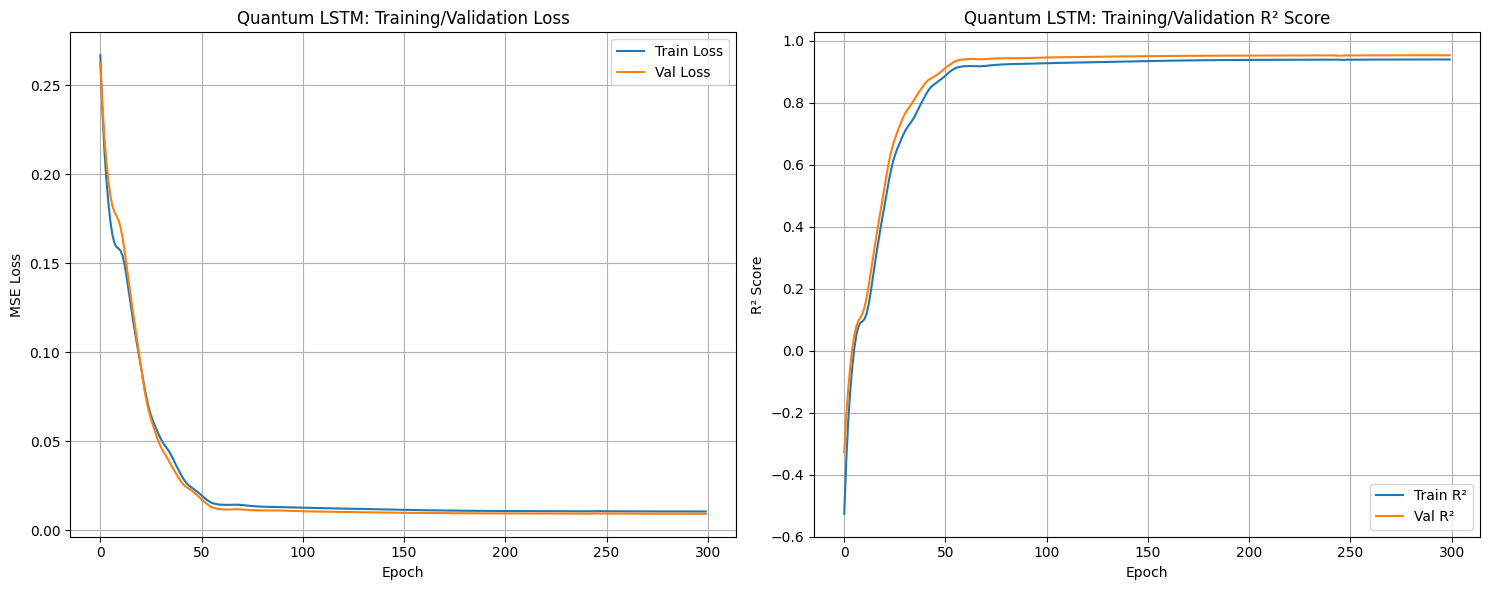

In [20]:
from sklearn.metrics import r2_score

# Quantum LSTM parameters
Qinput_dim = 8
Qhidden_dim = 32
Qn_qubits = 8
Qoutput_dim = 8
backend = 'default.qubit'
model = LSTMRegressor_8_dim(Qinput_dim, Qhidden_dim, output_dim=Qoutput_dim, n_qubits=Qn_qubits, backend=backend)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_function = nn.MSELoss()

# Training loop with metrics tracking
num_epochs = 300
train_loss_history = []
val_loss_history = []
train_r2_history = []
val_r2_history = []

# Convert tensors to numpy for metric calculations
y_train_np = y_train_tensor.numpy()
y_test_np = y_test_tensor.numpy()

for epoch in range(num_epochs):
    # Training phase
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    train_loss = loss_function(outputs[:,temp_c_index], y_train_tensor[:,temp_c_index])
    
    # Calculate training R²
    train_preds = outputs.detach().numpy()
    train_r2 = r2_score(y_train_np[:,temp_c_index], train_preds[:,temp_c_index], multioutput='uniform_average')
    
    train_loss.backward()
    optimizer.step()
    
    # Validation phase
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = loss_function(val_outputs[:,temp_c_index], y_test_tensor[:,temp_c_index])
        val_preds = val_outputs.numpy()
        val_r2 = r2_score(y_test_np[:,temp_c_index], val_preds[:,temp_c_index], multioutput='uniform_average')
    
    # Store metrics
    train_loss_history.append(train_loss.item())
    val_loss_history.append(val_loss.item())
    train_r2_history.append(train_r2)
    val_r2_history.append(val_r2)
    
    # Print epoch statistics
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f} Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")
# Plot metrics
plt.figure(figsize=(15, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.title('Quantum LSTM: Training/Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

# R² plot
plt.subplot(1, 2, 2)
plt.plot(train_r2_history, label='Train R²')
plt.plot(val_r2_history, label='Val R²')
plt.title('Quantum LSTM: Training/Validation R² Score')
plt.xlabel('Epoch')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

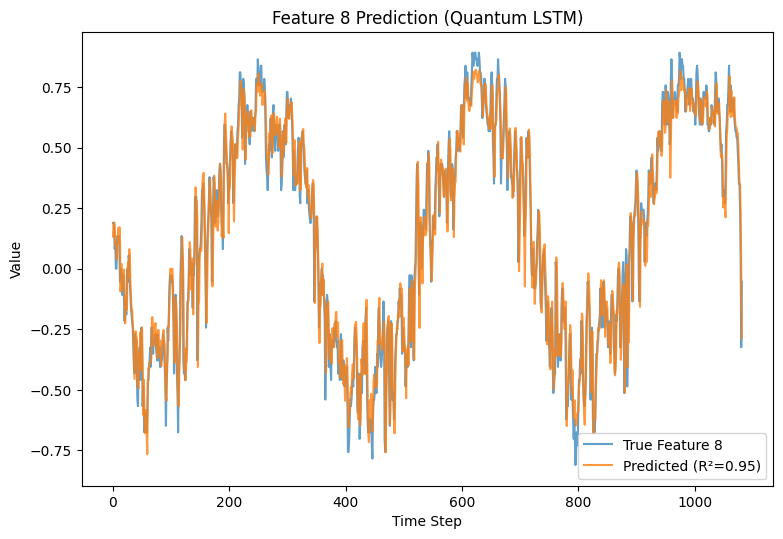


Quantum LSTM - Final Feature-wise Performance:
Feature 8: R² = 0.9536


In [21]:
# Final feature-wise evaluation
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).numpy()

# Calculate R² scores for each feature
feature_r2_scores = [r2_score(y_8_test[:, i], y_pred[:, i]) for i in range(8)]

# Plot predictions with individual R² scores
plt.figure(figsize=(15, 20))
for i in range(8):
    if i != temp_c_index:
        continue
    else:
        plt.subplot(4, 2, i+1)
        plt.plot(y_8_test[:, i], label=f'True Feature {i+1}', alpha=0.7)
        plt.plot(y_pred[:, i], label=f'Predicted (R²={feature_r2_scores[i]:.2f})', alpha=0.8)
        plt.title(f'Feature {i+1} Prediction (Quantum LSTM)')
        plt.xlabel('Time Step')
        plt.ylabel('Value')
        plt.legend()

plt.tight_layout()
plt.show()

# Print final feature metrics
print("\nQuantum LSTM - Final Feature-wise Performance:")
for i, r2 in enumerate(feature_r2_scores):
    if i != temp_c_index:
        continue
    else:
        print(f"Feature {i+1}: R² = {r2:.4f}")

In [22]:
# Function to calculate total number of parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Example: Assuming `model` is your PyTorch model
num_parameters = count_parameters(model)

print(f"The model has {num_parameters} trainable parameters.")

The model has 880 trainable parameters.


In [23]:
import numpy as np
import torch

def iterative_forecast_map(model, x_test, days_to_predict, scaler, device="cpu"):
    if isinstance(x_test, torch.Tensor):  # Ensure x_test is a NumPy array
        x_test = x_test.to(device).detach().numpy()

    n_samples, seq_len, n_features = x_test.shape
    prediction_dict = {}

    for step in range(1, days_to_predict + 1):
        predictions = []  # Store predictions for this step
        for i in range(n_samples - step + 1):
            # Get the initial sequence for the current sample
            sequence = torch.tensor(x_test[i], dtype=torch.float32, device=device).unsqueeze(0)  # Add batch dim

            # Use `seq_len - step` actual values and the remaining from predictions
            for t in range(step - 1):
                prediction = model(sequence)  # Forward pass instead of predict()
                prediction = prediction.squeeze(0).detach().cpu().numpy()  # Convert back to NumPy
                sequence = np.vstack((sequence.squeeze(0).cpu().numpy()[1:], prediction))  # Update sequence
                sequence = torch.tensor(sequence, dtype=torch.float32, device=device).unsqueeze(0)  # Convert back

            # Final prediction for the current step
            final_prediction = model(sequence).detach().cpu().numpy()
            predictions.append(final_prediction[0])

        # Convert predictions to array and inverse transform
        predictions = scaler.inverse_transform(np.array(predictions))

        # Store in dictionary with correct slicing
        prediction_dict[step] = predictions.reshape(-1, 1, n_features)

    return prediction_dict

In [24]:
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model.to(device)  # Move model to the correct device
# predictions = iterative_forecast_map(model, X_test_tensor, 4, scaler, device=device)


In [25]:
import numpy as np
import torch

def optimize_iterative_forecast_map(model, x_test, days_to_predict, scaler, device="cpu"):
    """Performs iterative multi-step forecasting efficiently using NumPy and PyTorch."""
    
    if isinstance(x_test, torch.Tensor):  # Convert PyTorch tensor to NumPy
        x_test = x_test.to(device).detach().cpu().numpy()

    n_samples, seq_len, n_features = x_test.shape
    prediction_dict = {}

    # Preallocate array for predictions
    predicted_sequences = np.zeros((n_samples, seq_len + days_to_predict, n_features))
    predicted_sequences[:, :seq_len, :] = x_test  # Initialize with test data

    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # Disable gradient tracking
        for step in range(1, days_to_predict + 1):
            # Extract current sequences for prediction
            current_sequences = predicted_sequences[:, step - 1: step - 1 + seq_len, :]
            current_sequences_tensor = torch.tensor(current_sequences, dtype=torch.float32, device=device)

            # Predict next step
            next_predictions = model(current_sequences_tensor).cpu().numpy()

            # Ensure shape is (n_samples, 1, n_features)
            next_predictions = next_predictions.reshape(n_samples, 1, n_features)

            # Store predictions
            predicted_sequences[:, seq_len + step - 1, :] = next_predictions[:, 0, :]

            # Save results after inverse transformation
            prediction_dict[step] = scaler.inverse_transform(next_predictions[:, 0, :])

    return prediction_dict


In [26]:
optimize_predictions_10 = optimize_iterative_forecast_map(model, X_test_tensor, 10, scaler, device=device)
optimize_predictions_10

NameError: name 'device' is not defined

In [ ]:
# predictions

In [ ]:
y_8_test_rescaled = scaler.inverse_transform(y_8_test)
y_8_test_rescaled

array([[ 54.3       ,  30.        ,  15.        , ...,  27.        ,
         17.        ,  27.68888889],
       [ 45.34      ,  20.        ,  12.        , ...,  29.        ,
         16.        ,  29.12777778],
       [ 42.52      , 350.        ,   8.        , ...,  29.        ,
         15.        ,  28.84444444],
       ...,
       [ 39.58      ,  30.        ,   9.        , ...,  28.        ,
         13.        ,  27.63888889],
       [ 34.69      ,  40.        ,  18.        , ...,  28.        ,
         11.        ,  27.33333333],
       [ 37.07      ,  30.        ,  14.        , ...,  28.        ,
         12.        ,  27.47777778]])

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

threshold = np.percentile(daily_max_temp["temp_c"], 90)

# Function to classify each day based on specified criteria
def classify_heatwave(data, threshold):
    # Convert data to NumPy array if it's a DataFrame or Series
    if isinstance(data, (pd.DataFrame, pd.Series)):
        data = data.values
    heatwave = [0] * len(data)  # Initialize the heatwave list with zeros
    for i in range(2, len(data)):
        if data[i] >= threshold:
            if data[i-1] >= threshold and data[i-2] >= threshold:
                heatwave[i] = 1
                heatwave[i-1] = 1
                heatwave[i-2] = 1
            else:
                heatwave[i] = 0
        else:
            heatwave[i] = 0
    return heatwave

# Example actual values (replace with your actual data)
actual_values = pd.DataFrame(y_test_rescaled).copy()

# Example prediction_dict (replace with your actual prediction_dict)
prediction_dict = predictions

# Initialize lists to store results
all_Precision = []
all_recall = []
all_f1score = []

# Loop through each horizon in prediction_dict
for step in range(1, len(prediction_dict) + 1):
    print(f"prediction num {step}\n")
    
    # Get predictions for the current horizon
    prediction = pd.DataFrame(predictions[step].reshape(len(actual_values) - (step - 1), 8))
    
    # Slice actual values to align with predictions
    temperory_actual_values = actual_values.iloc[step - 1:].copy()
    
    # Classify heatwave for actual values
    actual_heatwave_flags = classify_heatwave(temperory_actual_values[temp_c_index], threshold)
    temperory_actual_values["day_included_heatwave"] = actual_heatwave_flags
    
    # Classify heatwave for predicted values
    prediction_values_heatwave_flags = classify_heatwave(prediction[temp_c_index], threshold)
    prediction["day_included_heatwave"] = prediction_values_heatwave_flags
    
    # Extract heatwave columns
    y_true = temperory_actual_values['day_included_heatwave']
    y_pred = prediction['day_included_heatwave']
    
    # Compute evaluation metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # Append metrics to lists
    all_Precision.append(precision)
    all_recall.append(recall)
    all_f1score.append(f1)
    
    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'F1 Score: {f1:.2f}')
    
    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_true, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Heatwave', 'Heatwave'], yticklabels=['No Heatwave', 'Heatwave'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

NameError: name 'y_test_rescaled' is not defined